<a href="https://colab.research.google.com/github/Uzayulucay/RP_4q_code/blob/main/DoubleQSrFeO3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import Counter

In [ ]:
from sympy import symbols, lambdify, I, conjugate, exp, diff, re, im, expand_complex, expand, simplify, sin, cos, integrate, sqrt,sign

In [ ]:
from scipy.optimize import minimize

In [ ]:
nmax = 2
lamb = 100 #symbols("L")
J = 1
K = 0.005 #-0.0027
alpha1 = 8 #7.2
alpha2 = 7 #7.2
alpha3 = -0.3
alpha4 = 0.0
alpha5 = 0.0
a_l = 0
T = 0
b_l = 0

Hx = -0.00
Hy = -0.00
Hz = 0.00

In [ ]:
q1 = np.sqrt((J - alpha3/2)/(2*(alpha1 + alpha2)))
q2 = np.sqrt((J - alpha3)/(2*(alpha1 + alpha2)))
np.sqrt(q2)
-J*q1**2 + alpha1*q1**4 + alpha2*q1**4 + alpha3/2*q1**2 - (-J*q2**2 + alpha1*q2**4 + alpha2*q2**4 + alpha3*q2**2)

np.float64(0.0061249999999999916)

In [ ]:
np.sqrt(q1)
np.sqrt(q2)

np.float64(0.45625278075493775)

In [ ]:
def munit(x):
  e_3 = np.array([x[0],x[1],x[2]])
  return lamb*(e_3.dot(e_3) - 1)**2

In [ ]:
def munit_der(x):
  e_3 = np.array([x[0],x[1],x[2]])
  derlam = 2*lamb*(e_3.dot(e_3) - 1) * 2
  return  [derlam*e_3[0],derlam*e_3[1],derlam*e_3[2]]

In [ ]:
def singleq(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q = np.array([x[3],x[4],x[5]])
  return 3*K/8*(1 + sum(e_3**4)) + alpha3/2 * (q.dot(q) -  (q.dot(e_3))**2) + alpha2*sum(q**4) - J*q.dot(q) + alpha1*(q.dot(q))**2

In [ ]:
def spiral1q(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q = np.array([x[3],x[4],x[5]])
  return singleq(x) + munit(x)

In [ ]:
def spiral1q_der(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q = np.array([x[3],x[4],x[5]])
  dL = munit_der(x)

  x1 = 4 * 3*K/8 * e_3[0]**3 - alpha3 * q[0]*e_3.dot(q) + dL[0]
  x2 = 4 * 3*K/8 * e_3[1]**3 - alpha3 * q[1]*e_3.dot(q) + dL[1]
  x3 = 4 * 3*K/8 * e_3[2]**3 - alpha3 * q[2]*e_3.dot(q) + dL[2]
  xqx = 4*alpha2*q[0]**3 - 2*J*q[0] + 2*alpha1*2*q[0]*q.dot(q) +  alpha3 * (q[0] -  e_3[0]*e_3.dot(q))
  xqy = 4*alpha2*q[1]**3 - 2*J*q[1] + 2*alpha1*2*q[1]*q.dot(q) +  alpha3 * (q[1] -  e_3[1]*e_3.dot(q))
  xqz = 4*alpha2*q[2]**3 - 2*J*q[2] + 2*alpha1*2*q[2]*q.dot(q) +  alpha3 * (q[2] -  e_3[2]*e_3.dot(q))
  return np.array([x1,x2,x3,xqx,xqy,xqz])

In [ ]:
minima1q = minimize(spiral1q, x0 = [1,1,1,-1,-1,2], method = "BFGS", jac = spiral1q_der)#, jac = competition_derivative)
print(minima1q)
minima1q.x

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.029274039859459887
        x: [ 4.645e-01  4.645e-01  7.540e-01  1.339e-01  1.339e-01
            -1.404e-01]
      nit: 113
      jac: [-1.650e-06 -1.646e-06 -2.657e-06  3.886e-08  1.648e-08
            -1.899e-08]
 hess_inv: [[ 3.266e+02 -3.027e+02 ...  1.312e+00 -8.487e-01]
            [-3.027e+02  3.328e+02 ... -2.309e+00 -1.037e+00]
            ...
            [ 1.312e+00 -2.309e+00 ...  7.516e-01  2.105e-01]
            [-8.487e-01 -1.037e+00 ...  2.105e-01  5.767e-01]]
     nfev: 128
     njev: 128


array([ 0.46446551,  0.46446812,  0.75401133,  0.13393317,  0.13393313,
       -0.14035197])

In [ ]:
def e_check(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q = np.array([x[3],x[4],x[5]])
  return 3*K/8*(1 + sum(e_3**4)) + alpha3/2 * (q.dot(q) -  (q.dot(e_3))**2) + alpha2*sum(q**4) - J*q.dot(q) + alpha1*(q.dot(q))**2

In [ ]:
e_check(minima1q.x)

np.float64(-0.029274046378112057)

In [ ]:
def sinans(x):
  q = np.array([x[0],x[1],x[2]])
  return 0.5*alpha2*sum(q**4) - 0.5*J*q.dot(q)+ 0.5*alpha1*(q.dot(q))**2 + alpha3/6 * (sum(q))**2 + K/8

In [ ]:
def sinans_der(x):
  q = np.array([x[0],x[1],x[2]])
  x1 = 0.5*4*alpha2*q[0]**3 - 0.5*2*J*q[0] + 0.5*2*alpha1*2*q[0]*q.dot(q) +  alpha3/3 * (x[0] + x[1] + x[2])
  x2 = 0.5*4*alpha2*q[1]**3 - 0.5*2*J*q[1] + 0.5*2*alpha1*2*q[1]*q.dot(q) +  alpha3/3 * (x[0] + x[1] + x[2])
  x3 = 0.5*4*alpha2*q[2]**3 - 0.5*2*J*q[2] + 0.5*2*alpha1*2*q[2]*q.dot(q) +  alpha3/3 * (x[0] + x[1] + x[2])
  return [x1,x2,x3]

In [ ]:
def sinans3(x):
  q = np.array([0.127,0.127,0.127])
  return  + alpha3/2 *(0.127)**2*(x[0] + x[1] + x[2])**2  + lamb*(x[0]**2 + x[1]**2 + x[2]**2 - 1)**2 + 0.5*alpha2*sum(q**4) - 0.5*J*q.dot(q)+ 0.5*alpha1*(q.dot(q))**2 + 3*K/8*(x[0]**4 + x[1]**4 + x[2]**4)

In [ ]:
def sinans3_der(x):
  x1 = 4 * 3*K/8 * x[0]**3 + alpha3 *(0.127)**2*(x[0] + x[1] + x[2]) + 2*lamb*(x[0]**2 + x[1]**2 + x[2]**2 - 1) * 2 * x[0]
  x2 = 4 * 3*K/8 * x[1]**3 + alpha3 *(0.127)**2*(x[0] + x[1] + x[2]) + 2*lamb*(x[0]**2 + x[1]**2 + x[2]**2 - 1) * 2 * x[1]
  x3 = 4 * 3*K/8 * x[2]**3 + alpha3 *(0.127)**2*(x[0] + x[1] + x[2]) + 2*lamb*(x[0]**2 + x[1]**2 + x[2]**2 - 1) * 2 * x[2]
  return np.array([x1,x2,x3])

In [ ]:
minima = minimize(sinans, x0 = [-0.1,-0.1,0.1], method = "BFGS", jac = sinans_der)#, jac = competition_derivative)
print(minima)
minima.x #-0.012909011373876332

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.01981854838709662
        x: [-1.448e-01 -1.448e-01 -1.448e-01]
      nit: 13
      jac: [-3.529e-10 -3.529e-10  1.840e-08]
 hess_inv: [[ 8.158e-01 -1.842e-01 -2.468e-01]
            [-1.842e-01  8.158e-01 -2.468e-01]
            [-2.468e-01 -2.468e-01  8.709e-01]]
     nfev: 17
     njev: 17


array([-0.14480243, -0.14480243, -0.14480241])

In [ ]:
epsil = 0.3

In [ ]:
def state2q(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q2 = np.array([x[6],x[7],x[8]])
  return ((1 - epsil**2)*singleq(x)
  + epsil**2*(alpha2*sum(q2**4)
  - J*q2.dot(q2)
  + alpha1*(q2.dot(q2))**2
  + 3*K/8*(7 - 9*sum(e_3**4)) + alpha3 * (q2.dot(e_3))**2)
  + munit(x))

In [ ]:
def state2q_der(x):
  der = spiral1q_der(x)
  e_3 = np.array([x[0],x[1],x[2]])
  q2 = np.array([x[6],x[7],x[8]])

  x1 = (1 - epsil**2)*der[0] + epsil**2*(2*alpha3 * q2[0]*q2.dot(e_3) - 27*K/2*e_3[0]**3) + epsil**2*munit_der(x)[0]
  x2 = (1 - epsil**2)*der[1] + epsil**2*(2*alpha3 * q2[1]*q2.dot(e_3) - 27*K/2*e_3[1]**3) + epsil**2*munit_der(x)[1]
  x3 = (1 - epsil**2)*der[2] + epsil**2*(2*alpha3 * q2[2]*q2.dot(e_3) - 27*K/2*e_3[2]**3) + epsil**2*munit_der(x)[2]
  q1x = (1 - epsil**2)*der[3]
  q1y = (1 - epsil**2)*der[4]
  q1z = (1 - epsil**2)*der[5]
  q2x = epsil**2*(4*alpha2*q2[0]**3 - 2*J*q2[0] + 2*alpha1*2*q2[0]*q2.dot(q2) +  2*alpha3*e_3[0]*q2.dot(e_3))
  q2y = epsil**2*(4*alpha2*q2[1]**3 - 2*J*q2[1] + 2*alpha1*2*q2[1]*q2.dot(q2) +  2*alpha3*e_3[1]*q2.dot(e_3))
  q2z = epsil**2*(4*alpha2*q2[2]**3 - 2*J*q2[2] + 2*alpha1*2*q2[2]*q2.dot(q2) +  2*alpha3*e_3[2]*q2.dot(e_3))

  return np.array([x1,x2,x3,q1x,q1y,q1z,q2x,q2y,q2z])

In [ ]:
minima2q = minimize(state2q, x0 = [-1,-1,2,1,1,1,-1,-1,1], method = "BFGS", jac = state2q_der)#, jac = competition_derivative)
print(minima2q)
minima2q.x #-0.022454929850544703

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.02971578798982417
        x: [-7.776e-01 -4.446e-01  4.446e-01 -1.389e-01  1.348e-01
            -1.348e-01  1.611e-01  1.342e-01 -1.342e-01]
      nit: 233
      jac: [-1.597e-07 -9.598e-08  8.620e-08  3.660e-07 -8.897e-09
             8.228e-08  3.411e-08  1.100e-07 -3.300e-07]
 hess_inv: [[ 2.031e+01 -3.156e+01 ...  2.785e+00  8.306e-02]
            [-3.156e+01  2.436e+02 ... -2.655e+01 -1.809e+01]
            ...
            [ 2.785e+00 -2.655e+01 ...  7.443e+00  3.486e+00]
            [ 8.306e-02 -1.809e+01 ...  3.486e+00  5.033e+00]]
     nfev: 281
     njev: 281


array([-0.77762676, -0.44457754,  0.4445836 , -0.13889024,  0.13477033,
       -0.13477022,  0.16105512,  0.13416926, -0.13417149])

In [ ]:
np.arccos(-1/3)/np.pi*180 - np.arccos((minima2q.x[6:]/np.linalg.norm(minima2q.x[6:])).dot(1/np.sqrt(3)*np.array([1,1,1])))/np.pi*180

np.float64(54.73561031724535)

In [ ]:
def competition(x):
  e_3 = np.array([x[0],x[1],x[2]])
  q2 = np.array([x[6],x[7],x[8]])
  q1 = np.array([x[3],x[4],x[5]])
  return (#-singleq(x)
  #alpha2*sum(q2**4)
  #- J*q2.dot(q2)
  #+ alpha1*(q2.dot(q2))**2
  #+ alpha3 * (q2.dot(e_3))**2
  #+ 3*K/8*(7 - 9*sum(e_3**4))
  #-3*K/8*(1 + sum(e_3**4))
  #- (alpha2*sum(q1**4) - J*q1.dot(q1) + alpha1*(q1.dot(q1))**2 + alpha3/2 * (q1.dot(q1) -  (q1.dot(e_3))**2))
   )

In [ ]:
competition(minima2q.x)

np.float64(-0.007223400977654885)

In [ ]:
q2len = np.linalg.norm(minima2q.x[6:9])

In [ ]:
beta = np.sqrt(2)*alpha3/(6*alpha2*q2len**2 + 7*alpha3/2)
beta/np.pi*180

np.float64(17.72496966805148)

In [ ]:
-(K/2 - J**2/(4*alpha2/3 + 4*alpha1)) + 3*K/2 + 1/(alpha2/3 + alpha1)*(-1/4+alpha3/2*np.cos(np.arccos(-1/3)-beta)**2)

np.float64(0.003304204596977625)

In [ ]:
np.sqrt(1/(2*alpha2/3 + 2*alpha1)/3)

np.float64(0.17149858514250885)

In [ ]:
q2 = np.sqrt((1 - alpha3/9)/(2*alpha2/3 + 2*alpha1))
q2

np.float64(0.2920515667601508)

In [ ]:
np.sqrt(2)*alpha3/(6*alpha2*q2**2 + 7/2*alpha3)/np.pi*180

np.float64(-9.599191384810958)

In [ ]:
def indexes2(nmax):
  """Produces a list of coordinates of all points in reciprocal space
  . It also
  generates the inverted coordinates for complex conjugate variables.
  """
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
  indices = []
  ind2 = []
  for i in n:
    for j in np.arange(nmax + 1):
      if j != 0 or i >= 0:
        indices.append((i,j))
        ind2.append((-i,-j))

  return indices, ind2

In [ ]:
def factors(tup,comp,L):
  """comp is given as either [1,1] or [i,-i] depending on whether we are taking
  a derivative wrt the real part (A) or the imaginary part(B). Values in comp are
  the prefactors we get after taking the derivative. We treat the cases where a
  coefficients associated vector has a zero as a second component.
  """
  if tup < L:
    s = comp[0]
  else:
    s = comp[1]

  return s

In [ ]:
def comb_three(allcomb,N):
  """Similar to the first part of 'combinations', takes in all possible lists of 4 integers
  and the required N to produce the derivative terms. We require the sum of all elements
  to be not 0, but equal to minus the provided N.
  """

  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == -N:
      perm = list(set(itertools.permutations(allcomb[i],3)))
      for j in perm:
        list1.append(list(j))
  return list1

In [ ]:
def B4xyz(com,fac,C,indx):
  """Calculation of the 4th order terms that are not mixed (e.g. mx^4).
  Arrays must be arranged in such a way so that the components of each vector
  determine whether we consider a coefficient or its complex conjugate.
  C: An array of length 3. First element is a flat array in case the sign of the second component
  is 0. The proceeding matrices contain elements in the form of A + iB and A - iB respectively.
  com: indices for the 4th order terms.
  fac: combinatorial factors.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(4):
      b *= C[indx.index(com[i][j])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #expand(Add(*a))

In [ ]:
def b4xyz(com,fac,C,comp,indx):
  """Calculation of the derivatives of the 4th order non-mixed terms.
  """
  L = int(len(indx) + 1)/2
  a = []
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)
    for k in range(1,4):
      b *= C[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #expand(Add(*a))

In [ ]:
def B2xyz(com, fac, C1, C2,indx):
  """Calculation of the 4th order terms that are mixed (e.g. mx^2my^2).
  That is why C1 and C2 contain coefficients of different magnetization components.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(2):
      b *= C1[indx.index(com[i][j])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]

    a.append(np.prod(b))
  c = a*np.array(fac)

  #ad = sum(c)

  return c#ad

In [ ]:
def b2xyz(com, fac, C1, C2,comp,indx):
  """Calculation of the derivatives of the 4th order mixed terms.
  """
  a = []
  L = int(len(indx) + 1)/2
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)*C1[indx.index(com[i][1])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #ad

In [ ]:
def combinations2(nmax):
  """Takes in the integer bounds and produces lists for all distinct combinations
  of the indices that occur in the fourth order terms, as well as their combinatorial factors.
  """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,4)) #generate a list of 4 integers between -nmax and nmax

  #if the sum of integers within a list is 0 add all of its permutations to list1
  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == 0:
      perm = list(set(itertools.permutations(allcomb[i],4)))
      for j in perm:
        list1.append(list(j))


  comb_list1 = []
  comb_list2 = []
  for a in list1:
    for b in list1:
      z = list(zip(a,b)) #combine the lists into 4 vectors with 2 components
      comb_list1.append(tuple(sorted(z))) #ordering the vectors
      comb_list2.append(tuple(sorted(z[:2])+sorted(z[2:])))
      #ordering the first two elements and the last two separately for the mixed 4th order terms

  pos_comb1 = list(set(comb_list1)) #select all the distinct elements
  pos_comb2 = list(set(comb_list2))
  comb_fac1 = []
  comb_fac2 = []

  #count the distinct permutations of an element to find the combinatorial factors
  for i in range(len(pos_comb1)):
    comb_fac1.append(len(set(list(itertools.permutations(pos_comb1[i])))))

  for j in range(len(pos_comb2)):
    comb_fac2.append(len(set(list(itertools.permutations(pos_comb2[j][2:]))))*len(set(list(itertools.permutations(pos_comb2[j][:2])))))
  return pos_comb1, comb_fac1, pos_comb2, comb_fac2

In [ ]:
def comb_lists2(cr1, cr2, cor):
  """Lists are combined in groups of three and only after finding the distinct
  combinations, the fourth elements are added in order to find the combinatorial
  factors.
  """

  comb_list4b = []
  comb_list2b = []
  for a in cr1:
      for b in cr2:
        z = list(zip(a,b))
        comb_list4b.append(tuple(sorted(z)))
        comb_list2b.append(tuple(z[:1]+sorted(z[1:]))) #order the last two separately from the first element

  pos_comb4b = list(set(comb_list4b))
  pos_comb2b = list(set(comb_list2b))

  pc4b = []
  pc2b = []

  for el in pos_comb4b:
    pc4b.append(tuple(cor+list(el)))
    #adding the indices of the coefficient which we take the derivative with respect to

  for l in pos_comb2b:
    pc2b.append(tuple(cor+list(l)))

  return pc4b, pc2b

In [ ]:
def combinations_der2(x,nmax):
  """This produces the indices for the derivatives of the fourth power terms and
  their corresponding combinatorial factors.
  Supply x = [(a,b)] """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,3)) #this time lists contain 3 elements
  ind = [x[0][0],x[0][1],-x[0][0],-x[0][1]]
  #we need the vector and its inversion to demand complex conjugates are not treated separately

  coord = []
  for i in ind:
    coord.append(comb_three(allcomb, i))


  #derivative wrt the coefficient characterized by x and the complex conjugate of that term
  pc4b1, pc2b1 = comb_lists2(coord[0],coord[1],[(x[0][0],x[0][1])])
  pc4b2, pc2b2 = comb_lists2(coord[2],coord[3],[(-x[0][0],-x[0][1])])

  comb_fac4b = []
  comb_fac2b = []

  pc4 = list(set(sorted(pc4b1 + pc4b2)))
  pc2 = list(set(pc2b1 + pc2b2))


  prefac4b = []
  prefac2b = []

  for i in range(len(pc4)): #combinatorial factors
    comb_fac4b.append(len(set(list(itertools.permutations(pc4[i])))))
    prefac4b.append(pc4[i].count(pc4[i][0]))


  for i in range(len(pc2)): #combinatorial factors for the mixed terms
    comb_fac2b.append(len(set(list(itertools.permutations(pc2[i][:2]))))*len(set(list(itertools.permutations(pc2[i][2:])))))
    prefac2b.append(pc2[i][:2].count(pc2[i][0]))


  cf4 = np.array(prefac4b) * np.array(comb_fac4b)
  cf2 = np.array(prefac2b) * np.array(comb_fac2b)

  return pc4, cf4, pc2, cf2

In [ ]:
def norm(parameters,nmax):

  indx_pos, indx_neg = indexes2(nmax)
  indx = indx_pos + indx_neg[1:]
  arx, ary, arz = np.split(parameters[6:],3)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))

  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SySy = 2*Posy*Negy
  SySy[0] = SySy[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2
  #SqS-q terms

  S4x = B4xyz(com2[0],com2[1],X4,indx)
  S4y = B4xyz(com2[0],com2[1],Y4,indx)
  S4z = B4xyz(com2[0],com2[1],Z4,indx)

  S2xy = B2xyz(com2[2],com2[3],X4,Y4,indx)
  S2yz = B2xyz(com2[2],com2[3],Y4,Z4,indx)
  S2zx = B2xyz(com2[2],com2[3],Z4,X4,indx)

  Norm = sum(S4x + S4y + S4z) + 2*sum(S2xy + S2yz + S2zx) - 2 * sum(SxSx + SySy + SzSz) + 1
  return np.real(sum(SxSx + SySy + SzSz))

In [ ]:
def Spin2D_2q(param,w,r,t,nmax,th,ph):
  Qs = param[:6]
  sx, sy, sz = np.split(param[6:],3)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sya = sy[:L]; syb = np.append(0,sy[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])
  e = indexes2(nmax)[0]
  #S_x = sxa[0]
  #S_y = sya[0]
  #S_z = sza[0]
  S0 = np.array([sxa[0],sya[0],sza[0]])
  Rot_matrix = np.transpose(np.array([[np.cos(ph)*np.cos(th),-np.sin(ph),np.cos(ph)*np.sin(th)]
  ,[np.sin(ph)*np.cos(th),np.cos(ph),np.sin(ph)*np.sin(th)],
   [-np.sin(th),0,np.cos(th)]]))
  #Nv = np.dot(Rot_matrix,np.array([w,r,t]))
  W = w#Nv[0]
  R = r#Nv[1]
  T = t#Nv[2]
  #print(Rot_matrix)
  #print(np.transpose(Rot_matrix))

  S0rot = np.dot(Rot_matrix,S0)
  S_x = S0rot[0]
  S_y = S0rot[1]
  S_z = S0rot[2]

  for i in range(1,len(e)):
    Sa = np.dot(Rot_matrix,[sxa[i],sya[i],sza[i]])
    #print(Sa)
    SXa = Sa[0]
    SYa = Sa[1]
    SZa = Sa[2]
    Sb = np.dot(Rot_matrix,[sxb[i],syb[i],szb[i]])
    SXb = Sb[0]
    SYb = Sb[1]
    SZb = Sb[2]

    Q_x = e[i][0]*Qs[0] + e[i][1]*Qs[3]
    Q_y = e[i][0]*Qs[1] + e[i][1]*Qs[4]
    Q_z = e[i][0]*Qs[2] + e[i][1]*Qs[5]

    qx,qy,qz = np.dot(Rot_matrix,np.array([Q_x,Q_y,Q_z]))


    S_x += (2*SXa*np.cos(qx*W + qy*R + qz*T)
          - 2*SXb*np.sin(qx*W + qy*R + qz*T))
    S_y += (2*SYa*np.cos(qx*W + qy*R + qz*T)
          - 2*SYb*np.sin(qx*W + qy*R + qz*T))
    S_z += (2*SZa*np.cos(qx*W + qy*R + qz*T)
          - 2*SZb*np.sin(qx*W + qy*R + qz*T))
  return S_x, S_y, S_z


In [ ]:
def m4q4(param1, param2, com, B4):

  t = []
  ncom = np.split(param1*np.array(com)[:,:,:1].reshape(-1) + param2*np.array(com)[:,:,1:].reshape(-1),len(com))
  for i in range(len(ncom)):
    t.append(np.prod(ncom[i]))
  return t*B4

In [ ]:
def energy2(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):

  indx_pos, indx_neg = indexes2(nmax)
  indx = indx_pos + indx_neg[1:]
  arx, ary, arz = np.split(parameters[6:],3)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))


  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SySy = 2*Posy*Negy
  SySy[0] = SySy[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2

  SxSy = Posx*Negy + Posy*Negx
  SxSy[0] = SxSy[0]/2
  SySz = Posy*Negz + Posz*Negy
  SySz[0] = SySz[0]/2
  SzSx = Posz*Negx + Posx*Negz
  SzSx[0] = SzSx[0]/2
  #SqS-q terms

  com20 = com2[0]
  com21 = com2[1]
  com22 = com2[2]
  com23 = com2[3]

  q1x = parameters[0]; q2x = parameters[3]
  q1y = parameters[1]; q2y = parameters[4]
  q1z = parameters[2]; q2z = parameters[5]

  S4x = B4xyz(com20,com21,X4,indx)
  S4y = B4xyz(com20,com21,Y4,indx)
  S4z = B4xyz(com20,com21,Z4,indx)

  S2xy = B2xyz(com22,com23,X4,Y4,indx)
  S2yz = B2xyz(com22,com23,Y4,Z4,indx)
  S2zx = B2xyz(com22,com23,Z4,X4,indx)

  indx_pos = np.array(indx_pos)
  p1 = indx_pos[:,:1].reshape(-1)
  p2 = indx_pos[:,1:].reshape(-1)

  qx = p1*q1x + p2*q2x
  qy = p1*q1y + p2*q2y
  qz = p1*q1z + p2*q2z


  #Q4xS4 = m4q4(q1x,q2x,com20,S4x + S4y + S4z)
  #Q4yS4 = m4q4(q1y,q2y,com20,S4x + S4y + S4z)
  #Q4zS4 = m4q4(q1z,q2z,com20,S4x + S4y + S4z)

  #Q4xS2 = m4q4(q1x,q2x,com22,S2xy + S2yz + S2zx)
  #Q4yS2 = m4q4(q1y,q2y,com22,S2xy + S2yz + S2zx)
  #Q4zS2 = m4q4(q1z,q2z,com22,S2xy + S2yz + S2zx)


  exchange = (alpha1*(qx**2 + qy**2 + qz**2)**2 - J*(qx**2 + qy**2 + qz**2))*(SxSx + SySy + SzSz)
  SI_anisotropy = K*sum(S4x + S4y + S4z)
  ex4 = alpha2*(qx**4 + qy**4 + qz**4)*(SxSx + SySy + SzSz)
  anis2 = alpha3*(qx**2*SxSx + qy**2*SySy + qz**2*SzSz + 2*(qx*qy*SxSy + qy*qz*SySz + qz*qx*SzSx))
  anis2mix = alpha4*((qy**2 + qz**2)*SxSx + (qx**2 + qz**2)*SySy + (qx**2 + qy**2)*SzSz)

  Energy = (a_l * (T - 1)*sum(SxSx + SySy + SzSz) + b_l * (sum(S4x + S4y + S4z) + 2*sum(S2xy + S2yz + S2zx)) +
  + lamb*(sum(S4x + S4y + S4z) + 2*sum(S2xy + S2yz + S2zx) - 2 * sum(SxSx + SySy + SzSz) + 1) +
  sum(exchange + ex4 + anis2 + anis2mix) + SI_anisotropy #+ alpha5 * (sum(Q4xS4 + Q4yS4 + Q4zS4) + 2*sum(Q4xS2 + Q4yS2 + Q4zS2))
  - Hx*Ax[0] - Hy*Ay[0] - Hz*Az[0])

  return np.real(Energy)

In [ ]:
def q4m3(param, com, B4):

  q4xs3 = m4q4(param[0],param[3],com,B4)
  q4ys3 = m4q4(param[1],param[4],com,B4)
  q4zs3 = m4q4(param[2],param[5],com,B4)

  return sum(q4xs3 + q4ys3 + q4zs3)

In [ ]:
def derivatives2(indices,parameters, comp, nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  """derivatives of energy wrt the Fourier coefficients. The derivative for the
  coefficient associated with (0,0) is treated differently since it has no imaginary part"""

  in_pos, in_neg = indexes2(nmax)
  indx = in_pos + in_neg[1:]
  arx, ary, arz = np.split(parameters[6:],3) #parameters[9:]
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))


  p1 = np.array(in_pos)[:,:1].reshape(-1)
  p2 = np.array(in_pos)[:,1:].reshape(-1)

  q1x = parameters[0]; q2x = parameters[3]
  q1y = parameters[1]; q2y = parameters[4]
  q1z = parameters[2]; q2z = parameters[5]

  qx = p1*q1x + p2*q2x
  qy = p1*q1y + p2*q2y
  qz = p1*q1z + p2*q2z

  dEx = []
  dEy = []
  dEz = []
  for i in range(len(indices)):

    indX = in_pos.index(indices[i])
    Cod = cod2[indX]
    Cod0 = Cod[0]; Cod1 = Cod[1]; Cod2 = Cod[2]; Cod3 = Cod[3]
    S4x = b4xyz(Cod0, Cod1,X4,comp,indx)
    S4y = b4xyz(Cod0, Cod1,Y4,comp,indx)
    S4z = b4xyz(Cod0, Cod1,Z4,comp,indx)

    S2xy = b2xyz(Cod2, Cod3,X4, Y4,comp,indx)
    S2xz = b2xyz(Cod2, Cod3,X4, Z4,comp,indx)
    S2yx = b2xyz(Cod2, Cod3,Y4, X4,comp,indx)
    S2yz = b2xyz(Cod2, Cod3,Y4, Z4,comp,indx)
    S2zx = b2xyz(Cod2, Cod3,Z4, X4,comp,indx)
    S2zy = b2xyz(Cod2, Cod3,Z4, Y4,comp,indx)

    #q4s3x = q4m3(parameters[:6],Cod0,S4x)
    #q4s3y = q4m3(parameters[:6],Cod0,S4y)
    #q4s3z = q4m3(parameters[:6],Cod0,S4z)

    #q4s2x = q4m3(parameters[:6],Cod2,S2xy + S2xz)
    #q4s2y = q4m3(parameters[:6],Cod2,S2yx + S2yz)
    #q4s2z = q4m3(parameters[:6],Cod2,S2zx + S2zy)

    qX = qx[indX]
    qY = qy[indX]
    qZ = qz[indX]

    dSxSx = 2.0*comp[1]*Posx[indX] + 2.0*comp[0]*Negx[indX]
    dSySy = 2.0*comp[1]*Posy[indX] + 2.0*comp[0]*Negy[indX]
    dSzSz = 2.0*comp[1]*Posz[indX] + 2.0*comp[0]*Negz[indX]

    if indX == 0:
      dSxSx = dSxSx/2
      dSySy = dSySy/2
      dSzSz = dSzSz/2
      Hfx = Hx
      Hfy = Hy
      Hfz = Hz
    else:
      Hfx = 0
      Hfy = 0
      Hfz = 0



    dEx.append(lamb*(sum(S4x) + 2*sum(S2xy + S2xz) - 2*dSxSx) + K*sum(S4x) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSxSx +
      alpha2*dSxSx*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qX**2*dSxSx + 2*(qX*qY*0.5*dSySy + qZ*qX*0.5*dSzSz)) +
      alpha4*(qY**2 + qZ**2)*dSxSx - Hfx + a_l*(T - 1)*dSxSx + b_l*(sum(S4x) + 2*sum(S2xy + S2xz)))
      #+ alpha5*(q4s3x + 2*q4s2x))


    dEy.append(lamb*(sum(S4y) + 2*sum(S2yx + S2yz) - 2*dSySy) + K*sum(S4y) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSySy +
      alpha2*dSySy*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qY**2*dSySy + 2*(qX*qY*0.5*dSxSx + qZ*qY*0.5*dSzSz)) +
      alpha4*(qX**2 + qZ**2)*dSySy - Hfy + a_l*(T - 1)*dSySy + b_l*(sum(S4y) + 2*sum(S2yx + S2yz)))
      #+ alpha5*(q4s3y + 2*q4s2y))

    dEz.append(lamb*(sum(S4z) + 2*sum(S2zy + S2zx) - 2*dSzSz)  + K*sum(S4z) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSzSz +
      alpha2*dSzSz*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qZ**2*dSzSz + 2*(qX*qZ*0.5*dSxSx + qZ*qY*0.5*dSySy)) +
      alpha4*(qX**2 + qY**2)*dSzSz - Hfz + a_l*(T - 1)*dSzSz + b_l*(sum(S4z) + 2*sum(S2zy + S2zx)))
      #+ alpha5*(q4s3z + 2*q4s2z))

  return np.array(dEx), np.array(dEy), np.array(dEz)

In [ ]:
def m4q3(param1, param2, com, B4):

  w1 = np.array(np.split(np.array(com)[:,:,:1].reshape(-1),len(com)))
  w2 = np.array(np.split(np.array(com)[:,:,1:].reshape(-1),len(com)))
  w = param1*w1 + param2*w2
  t1 = []
  t2 = []
  for i in range(len(com)):
    W = w[i]; W1 = w1[i]; W2 = w2[i]
    t1.append((W1[0]*W[1]*W[2]*W[3] + W1[1]*W[0]*W[2]*W[3] + W1[2]*W[0]*W[1]*W[3] + W1[3]*W[0]*W[1]*W[2])*B4[i])
    t2.append((W2[0]*W[1]*W[2]*W[3] + W2[1]*W[0]*W[2]*W[3] + W2[2]*W[0]*W[1]*W[3] + W2[3]*W[0]*W[1]*W[2])*B4[i])
  return sum(t1), sum(t2)

In [ ]:
def der_2q(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  indx_pos, indx_neg = indexes2(nmax)
  indx = indx_pos + indx_neg[1:]
  indx_pos = np.array(indx_pos)
  arx, ary, arz = np.split(parameters[6:],3) #parameters[9:]
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))

  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SySy = 2*Posy*Negy
  SySy[0] = SySy[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2
  SxSy = Posx*Negy + Posy*Negx
  SxSy[0] = SxSy[0]/2
  SySz = Posy*Negz + Posz*Negy
  SySz[0] = SySz[0]/2
  SzSx = Posz*Negx + Posx*Negz
  SzSx[0] = SzSx[0]/2

  com20 = com2[0]
  com21 = com2[1]
  com22 = com2[2]
  com23 = com2[3]

  S4x = B4xyz(com20,com21,X4,indx)
  S4y = B4xyz(com20,com21,Y4,indx)
  S4z = B4xyz(com20,com21,Z4,indx)

  S2xy = B2xyz(com22,com23,X4,Y4,indx)
  S2yz = B2xyz(com22,com23,Y4,Z4,indx)
  S2zx = B2xyz(com22,com23,Z4,X4,indx)

  q1x = parameters[0]; q2x = parameters[3]
  q1y = parameters[1]; q2y = parameters[4]
  q1z = parameters[2]; q2z = parameters[5]

  #dq41x, dq42x = m4q3(q1x,q2x,com20,S4x + S4y + S4z)
  #dq41y, dq42y = m4q3(q1y,q2y,com20,S4x + S4y + S4z)
  #dq41z, dq42z = m4q3(q1z,q2z,com20,S4x + S4y + S4z)

  #dq21x, dq22x = m4q3(q1x,q2x,com22,S2xy + S2yz + S2zx)
  #dq21y, dq22y = m4q3(q1y,q2y,com22,S2xy + S2yz + S2zx)
  #dq21z, dq22z = m4q3(q1z,q2z,com22,S2xy + S2yz + S2zx)

  indx_pos = np.array(indx_pos)
  p1 = indx_pos[:,:1].reshape(-1)
  p2 = indx_pos[:,1:].reshape(-1)

  dqx = p1*q1x + p2*q2x
  dqy = p1*q1y + p2*q2y
  dqz = p1*q1z + p2*q2z

  qx = p1
  qy = p1
  qz = p1

  derq1x = (sum(-J*2*dqx*qx*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqx*qx*(SxSx + SySy + SzSz))
  + alpha2*(4*qx*dqx**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqx*qx*SxSx + 2*(qx*dqy*SxSy + dqz*qx*SzSx))
  + alpha4*2*qx*(dqx*SySy + dqx*SzSz)))
  #+ alpha5*(dq41x + 2*dq21x))


  derq1y = (sum(-J*2*dqy*qy*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqy*qy*(SxSx + SySy + SzSz))
  + alpha2*(4*qy*dqy**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqy*qy*SySy + 2*(qy*dqx*SxSy + dqz*qy*SySz))
  + alpha4*2*qy*(dqy*SxSx + dqy*SzSz)))
  #+ alpha5*(dq41y + 2*dq21y))

  derq1z = (sum(-J*2*dqz*qz*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqz*qz*(SxSx + SySy + SzSz))
  + alpha2*(4*qz*dqz**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqz*qz*SzSz + 2*(dqx*qz*SzSx + dqy*qz*SySz))
  + alpha4*2*qz*(dqz*SxSx + dqz*SySy)))
  #+ alpha5*(dq41z + 2*dq21z))

  qx = p2
  qy = p2
  qz = p2

  derq2x = (sum(-J*2*dqx*qx*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqx*qx*(SxSx + SySy + SzSz))
  + alpha2*(4*qx*dqx**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqx*qx*SxSx + 2*(qx*dqy*SxSy + dqz*qx*SzSx))
  + alpha4*2*qx*(dqx*SySy + dqx*SzSz)))
  #+ alpha5*(dq42x + 2*dq22x))

  derq2y = (sum(-J*2*dqy*qy*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqy*qy*(SxSx + SySy + SzSz))
  + alpha2*(4*qy*dqy**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqy*qy*SySy + 2*(qy*dqx*SxSy + dqz*qy*SySz))
  + alpha4*2*qy*(dqy*SxSx + dqy*SzSz)))
  #+ alpha5*(dq42y + 2*dq22y))

  derq2z = (sum(-J*2*dqz*qz*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqz*qz*(SxSx + SySy + SzSz))
  + alpha2*(4*qz*dqz**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqz*qz*SzSz + 2*(dqx*qz*SzSx + dqy*qz*SySz))
  + alpha4*2*qz*(dqz*SxSx + dqz*SySy)))
  #+ alpha5*(dq42z + 2*dq22z))



  return derq1x, derq1y, derq1z, derq2x, derq2y, derq2z

In [ ]:
def der2(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  """The full gradient function"""
  indx_pos, indx_neg = indexes2(nmax)
  indx = indx_pos + indx_neg[1:]

  Eax, Eay, Eaz = derivatives2(indx_pos,parameters,[1,1], nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  Ebx, Eby, Ebz = derivatives2(indx_pos[1:],parameters,[1j,-1j], nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  der_q1x, der_q1y, der_q1z, der_q2x, der_q2y, der_q2z = der_2q(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  return np.real(np.concatenate(([der_q1x, der_q1y, der_q1z, der_q2x, der_q2y, der_q2z],Eax,Ebx,Eay,Eby,Eaz,Ebz)))

In [ ]:
def input_arrays2(zero_ar,param,nmax):
  arx, ary, arz = np.split(param[6:],3)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  ar_zero = np.copy(zero_ar)
  all_arrays = [Ax,Bx,Ay,By,Az,Bz]
  e = indexes2(nmax)[0]
  for k in range(6):
    for i in range(len(e)):
      ar_zero[k][e[i]] = all_arrays[k][i]
  return ar_zero

In [ ]:
def generate_param2(inp_ar,nmax):
  """Converts the matrices from input_arrays into a 1D array to be fed into the minimization
  algorithm"""
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
  inp_arrays = []
  for i in range(6):
    if i%2 == 0:
      for k in n:
        for j in np.arange(nmax + 1):
          if j != 0 or k >= 0:
            inp_arrays.append(inp_ar[i][k,j])
    else:
      for k in n:
        for j in np.arange(nmax + 1):
          if j != 0 or k > 0:
              inp_arrays.append(inp_ar[i][k,j])
  return inp_arrays

In [ ]:
def domain(q1d, s1):
  in_ar2q1 = input_arrays2(np.zeros((6,5,3)),np.zeros(81),2)

  if q1d == [1,-1,1]:
    si = [-1,1,1,1]
  elif q1d == [-1,1,1]:
    si = [1,-1,-1,-1]
  elif q1d == [1,1,1]:
    si = [-1,-1,-1,1]
  elif q1d == [-1,-1,1]:
    si = [1,1,1,-1]

  in_ar2q1[0,1,0] = 1/(2*np.sqrt(6))*si[0]
  in_ar2q1[2,1,0] = 1/(2*np.sqrt(6))*si[1]
  in_ar2q1[4,1,0] = 1/(np.sqrt(6))
  in_ar2q1[1,1,0] = 1/(2*np.sqrt(2))*si[2]
  in_ar2q1[3,1,0] = 1/(2*np.sqrt(2))*si[3]


  in_ar2q1[0,0,1] = 0.1/(np.sqrt(3))*q1d[0]
  in_ar2q1[2,0,1] = 0.1/(np.sqrt(3))*q1d[1]
  in_ar2q1[4,0,1] = 0.1/(np.sqrt(3))*q1d[2]
  in_ar2q1[1,0,1] = 0.1/(np.sqrt(3))*q1d[0]
  in_ar2q1[3,0,1] = 0.1/(np.sqrt(3))*q1d[1]
  in_ar2q1[5,0,1] = 0.1/(np.sqrt(3))*q1d[2]

  in_arrays2q1 = np.concatenate((np.array([q1d[0]*0.13,q1d[1]*0.13,q1d[2]*0.13,s1[0]*0.13,s1[1]*0.13,s1[2]*0.13]),generate_param2(in_ar2q1,2)))
  return in_arrays2q1

In [ ]:
dom11 = domain([1,1,1],[-1,-1,1])
dom12 = domain([1,1,1],[-1,1,-1])
dom13 = domain([1,1,1],[1,-1,-1])
dom21 = domain([-1,-1,1],[1,1,1])
dom22 = domain([-1,-1,1],[-1,1,-1])
dom23 = domain([-1,-1,1],[1,-1,-1])
dom31 = domain([1,-1,1],[1,1,-1])
dom32 = domain([1,-1,1],[-1,-1,-1])
dom33 = domain([1,-1,1],[-1,1,1])
dom41 = domain([-1,1,1],[1,1,-1])
dom42 = domain([-1,1,1],[-1,-1,-1])
dom43 = domain([-1,1,1],[1,-1,1])
domains = [dom11, dom12, dom13, dom21, dom22, dom23, dom31, dom32, dom33, dom41, dom42, dom43]

In [ ]:
nmax = 2

In [ ]:
com2 = combinations2(nmax)

In [ ]:
cod2 = []
e2 = indexes2(nmax)[0]
for ic in e2:
  cod2.append(combinations_der2([ic],nmax))

In [ ]:
ou = []
Ener = []
for i in range(len(domains)):
  res2q = minimize(energy2, x0 = domains[i], method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha5,
          Hx, Hy, Hz, lamb, com2, cod2), jac = der2)
  output2q = res2q.x
  Ener.append(res2q.fun)
  print(res2q)
  print(output2q)
  ou.append(output2q)

TypeError: energy2() missing 4 required positional arguments: 'cod2', 'a_l', 'T', and 'b_l'

In [ ]:
domains[0][:6], domains[3][:6], domains[8][:6], domains[11][:6]

(array([ 0.13,  0.13,  0.13, -0.13, -0.13,  0.13]),
 array([-0.13, -0.13,  0.13,  0.13,  0.13,  0.13]),
 array([ 0.13, -0.13,  0.13, -0.13,  0.13,  0.13]),
 array([-0.13,  0.13,  0.13,  0.13, -0.13,  0.13]))

In [ ]:
domains[2][:6], domains[4][:6], domains[6][:6], domains[10][:6]

(array([ 0.13,  0.13,  0.13,  0.13, -0.13, -0.13]),
 array([-0.13, -0.13,  0.13, -0.13,  0.13, -0.13]),
 array([ 0.13, -0.13,  0.13,  0.13,  0.13, -0.13]),
 array([-0.13,  0.13,  0.13, -0.13, -0.13, -0.13]))

In [ ]:
in_ar2q1 = input_arrays2(np.zeros((6,5,3)),np.zeros(81),2)

"""in_ar2q1[0,1,0] = -0.1/(2*np.sqrt(6))
in_ar2q1[2,1,0] = -0.1/(2*np.sqrt(6))
in_ar2q1[4,1,0] = 0.1/(np.sqrt(6))
in_ar2q1[1,1,0] = -0.1/(2*np.sqrt(2))
in_ar2q1[3,1,0] = 0.1/(2*np.sqrt(2))

in_ar2q1[0,0,1] = 0.1/(2*np.sqrt(6))
in_ar2q1[2,0,1] = 0.1/(2*np.sqrt(6))
in_ar2q1[4,0,1] = 0.1/(np.sqrt(6))
in_ar2q1[1,0,1] = 0.1/(2*np.sqrt(2))
in_ar2q1[3,0,1] = -0.1/(2*np.sqrt(2))

in_ar2q1[0,1,1] = 0.1/(2*np.sqrt(6))
in_ar2q1[2,1,1] = 0.1/(2*np.sqrt(6))
in_ar2q1[4,1,1] = 0.1/(np.sqrt(6))
in_ar2q1[1,1,1] = 0.1/(2*np.sqrt(2))
in_ar2q1[3,1,1] = -0.1/(2*np.sqrt(2))"""

"""in_ar2q1[0,1,0] = -1/(2*np.sqrt(6))
in_ar2q1[2,1,0] = -1/(2*np.sqrt(6))
in_ar2q1[4,1,0] = 1/(np.sqrt(6))
in_ar2q1[1,1,0] = -1/(2*np.sqrt(2))
in_ar2q1[3,1,0] = 1/(2*np.sqrt(2))

in_ar2q1[0,0,1] = 1/(2*np.sqrt(6))
in_ar2q1[2,0,1] = 1/(2*np.sqrt(6))
in_ar2q1[4,0,1] = 1/(np.sqrt(6))
in_ar2q1[1,0,1] = 1/(2*np.sqrt(2))
in_ar2q1[3,0,1] = -1/(2*np.sqrt(2))"""


"""in_ar2q1[1,1,0] = 0.05
in_ar2q1[3,1,0] = 0.05
in_ar2q1[5,1,0] = 0.05
in_ar2q1[0,1,0] = 0.05
in_ar2q1[2,1,0] = 0.05
in_ar2q1[4,1,0] = 0.05
#in_ar2q1[1,1,0] = 1/(2)
#in_ar2q1[3,1,0] = -1/(2)

in_ar2q1[0,0,1] = -0.05
in_ar2q1[2,0,1] = -0.05
in_ar2q1[4,0,1] = 0.05
in_ar2q1[1,0,1] = -0.05
in_ar2q1[3,0,1] = -0.05
in_ar2q1[5,0,1] = 0.05"""

in_ar2q1[3,1,0] = -0.02
in_ar2q1[4,1,0] = 0.02

in_ar2q1[0,0,1] = 0.05
#in_ar2q1[5,0,1] = -0.05

in_arrays2q1 = np.concatenate((np.array([0.14,0.0,0.0,0.0,0.14,0.0]),generate_param2(in_ar2q1,2)))
in_arrays2q1

array([ 0.14,  0.  ,  0.  ,  0.  ,  0.14,  0.  ,  0.  ,  0.05,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  , -0.02,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.02,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ])

In [ ]:
nmax = 2
lamb = 100 #symbols("L")
J = 1
K = -0.002
alpha1 = 8
alpha2 = 7 #-1
alpha3 = 0.3 #-2
alpha4 = 0
alpha5 = 0
a_l = 0.0
T = 0
b_l = 0


Hx = 0.003
Hy = 0.003
Hz = 0.003

In [ ]:
def coef2(recomp,imcomp,nmax):
    """This is for symbolic checks.
    """
    Rx = []
    Ix = []

    n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))

    for i in n:
      for j in np.arange(nmax + 1):
        if j != 0 or i >= 0:
          Rx.append(symbols(f"{recomp}_{i}{j}",real = True))
          Ix.append(symbols(f"{imcomp}_{i}{j}",real = True))

    return Rx+Ix[1:]

In [ ]:
doubleq = np.array([-3.14603149e-09,  0.00000000e+00,  7.58022904e-01,  7.79001302e-01,
        0.00000000e+00, -2.56902149e-07,  0.00000000e+00,  8.56545232e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  2.87601033e-04,  0.00000000e+00,  2.87606789e-04,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  9.22933633e-08,  0.00000000e+00, -2.16158671e-05,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -2.16222522e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.96462251e-01,  0.00000000e+00,
       -1.75575182e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.75575226e-03,
        7.75571438e-06,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.78130777e-06,  0.00000000e+00,
       -1.78341276e-06,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.82389007e-08,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.25536151e-06,
        0.00000000e+00, -2.25822479e-06,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  4.96995454e-01,
        0.00000000e+00, -1.71049486e-03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.71049209e-03])

In [ ]:
doublq = np.array([-7.49323415e-10,  0.00000000e+00,  7.58022882e-01,  7.79000307e-01,
        0.00000000e+00,  1.04706846e-07,  0.00000000e+00,  8.56545542e-02,
        0.00000000e+00, -3.93254819e-08,  0.00000000e+00, -2.16289388e-05,
        0.00000000e+00, -2.87600668e-04,  0.00000000e+00, -2.87600962e-04,
        0.00000000e+00,  0.00000000e+00,  2.16289066e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -7.76152771e-06,  0.00000000e+00,  4.96462251e-01,  0.00000000e+00,
       -1.75575189e-03,  0.00000000e+00, -1.78565436e-06,  0.00000000e+00,
       -1.78589839e-06,  0.00000000e+00,  0.00000000e+00,  1.75575305e-03,
        0.00000000e+00,  7.17174708e-09,  0.00000000e+00,  4.96995452e-01,
        0.00000000e+00, -1.71049437e-03,  0.00000000e+00, -2.25955828e-06,
        0.00000000e+00,  2.25951689e-06,  0.00000000e+00,  0.00000000e+00,
       -1.71049573e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00])

In [ ]:
doubleqsin = np.array([ 2.04778475e-07,  0.00000000e+00,  8.06186543e-01,  8.06188375e-01,
        0.00000000e+00, -2.22422863e-07,  0.00000000e+00, -1.10731619e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -8.65247756e-05,  0.00000000e+00, -8.65163949e-05,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -5.44292801e-08,  0.00000000e+00,  1.10343254e-06,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.09310146e-06,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.23241793e-07,  0.00000000e+00,
        3.12630045e-09,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.37315825e-09,
       -1.55988914e-07,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.75981826e-08,  0.00000000e+00,
        1.43269844e-08,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  8.75653554e-08,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.08903717e-06,
        0.00000000e+00,  1.10703469e-06,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.10731100e-01,
        0.00000000e+00,  8.65225652e-05,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -8.65218329e-05])

In [ ]:
doubleq2 = np.array([ 1.35792240e-01,  1.35792254e-01,  1.36704240e-01, -1.33411851e-01,
       -1.33410568e-01,  1.43316356e-01,  0.00000000e+00,  6.40662183e-02,
        0.00000000e+00,  2.35867266e-01,  0.00000000e+00, -1.36836073e-03,
        0.00000000e+00, -1.38200893e-03,  0.00000000e+00, -6.96132520e-04,
        0.00000000e+00,  0.00000000e+00, -2.28579455e-03,  1.02276556e-02,
        0.00000000e+00,  3.73898097e-01,  0.00000000e+00, -7.56101137e-03,
        0.00000000e+00, -1.15720263e-03,  0.00000000e+00,  3.12071701e-04,
        0.00000000e+00,  0.00000000e+00,  2.05637015e-03,  0.00000000e+00,
        6.39751819e-02,  0.00000000e+00,  3.13826576e-01,  0.00000000e+00,
       -6.68741986e-03,  0.00000000e+00, -1.79655363e-03,  0.00000000e+00,
       -7.30252565e-04,  0.00000000e+00,  0.00000000e+00, -1.23824655e-03,
        1.07725365e-02,  0.00000000e+00, -3.11365130e-01,  0.00000000e+00,
        3.78422480e-03,  0.00000000e+00, -1.46103338e-04,  0.00000000e+00,
       -2.20698071e-04,  0.00000000e+00,  0.00000000e+00, -2.81430966e-03,
        0.00000000e+00, -1.18805931e-01,  0.00000000e+00,  2.91587942e-01,
        0.00000000e+00, -4.32647838e-03,  0.00000000e+00,  1.80951856e-03,
        0.00000000e+00,  7.18242511e-04,  0.00000000e+00,  0.00000000e+00,
       -1.80796996e-03, -1.94854593e-02,  0.00000000e+00,  3.31756753e-02,
        0.00000000e+00, -2.02846387e-03,  0.00000000e+00,  7.41955820e-04,
        0.00000000e+00, -4.60082645e-05,  0.00000000e+00,  0.00000000e+00,
       -3.88816007e-04])

In [ ]:
hcon = np.array([ 1.26683414e-01,  1.26678122e-01,  1.27491824e-01, -1.12967270e-01,
       -1.13007056e-01,  1.35854974e-01,  7.01900861e-02,  4.16144620e-02,
        2.21292736e-04, -2.04997227e-01, -1.15942378e-03, -2.63421953e-03,
       -4.02954308e-05, -1.08635241e-04, -2.13188176e-05,  1.81387852e-04,
       -5.28628551e-06,  2.92180164e-03,  1.34385750e-03,  4.27560598e-02,
       -3.66301783e-04, -3.46661653e-01,  7.79350461e-03,  1.44297887e-03,
       -6.48978552e-05,  3.89523409e-04,  8.17802056e-06, -5.17504219e-05,
       -4.89897356e-06, -1.32706223e-03,  8.39541495e-04,  7.01814569e-02,
        4.14695915e-02, -1.98328447e-04, -2.04345229e-01,  7.82823429e-03,
        2.54511126e-03, -3.95387654e-05,  3.92067708e-04,  2.09177735e-05,
       -5.78428514e-05,  5.63103555e-06, -1.42158269e-03, -1.39382023e-03,
        4.28845166e-02, -3.78080927e-04,  3.47084316e-01, -9.42843886e-04,
        1.59510369e-03,  6.57062023e-05, -9.78418786e-05,  9.22413374e-06,
        1.79418006e-04, -4.55127139e-06,  2.87850621e-03,  7.53910058e-04,
        7.21229837e-02,  4.34902672e-02,  1.30952020e-05,  3.96068029e-01,
       -4.20336053e-03,  8.72417028e-05,  7.85526986e-05, -2.77200910e-04,
        7.12076577e-07, -1.35360264e-04, -1.24325133e-07, -2.90441421e-03,
        4.90105965e-05,  4.48298147e-02, -4.42014094e-04, -3.52850472e-04,
       -4.32992217e-03, -2.96607375e-03, -2.54686522e-07, -2.84535257e-04,
       -2.80634790e-05, -1.40181709e-04,  4.66687241e-06, -2.99848064e-03,
       -1.57061916e-03])

In [ ]:
res2q = minimize(energy2, x0 = hcon, method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5,
        Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l), jac = der2)
output2q = res2q.x
print(res2q)
output2q #-0.014399999907863779

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.025499081622846143
        x: [ 1.270e-01  1.270e-01 ... -8.034e-04 -1.096e-04]
      nit: 199
      jac: [-3.111e-09 -4.608e-09 ... -6.937e-07  4.229e-06]
 hess_inv: [[ 8.261e-01 -1.996e-01 ...  6.546e-02  1.583e-02]
            [-1.996e-01  7.962e-01 ...  2.347e-02  5.710e-03]
            ...
            [ 6.546e-02  2.347e-02 ...  1.412e+00  3.867e-02]
            [ 1.583e-02  5.710e-03 ...  3.867e-02  1.925e-01]]
     nfev: 242
     njev: 242


array([ 1.26982536e-01,  1.26982193e-01,  1.27030618e-01, -1.12688127e-01,
       -1.12678873e-01,  1.43440019e-01,  6.71000278e-02,  1.03532610e-02,
        1.44586058e-05, -2.03057668e-01, -3.28359692e-04, -1.56902599e-04,
       -3.39702363e-06, -2.67284143e-05, -7.75454438e-07,  4.55469860e-05,
       -6.23771102e-07,  7.52829437e-04,  8.83674480e-05,  1.09946472e-02,
       -4.06580786e-05, -3.50801443e-01,  1.67624573e-03,  7.88908374e-05,
       -2.80971540e-06,  9.09107707e-05, -4.14825632e-07, -1.29741166e-05,
       -7.28247924e-07, -3.47996609e-04,  5.41711181e-05,  6.70997707e-02,
        1.03306103e-02, -9.07513813e-06, -2.02624217e-01,  1.69703690e-03,
        1.46142327e-04, -3.32982641e-06,  9.22527357e-05,  6.24775859e-07,
       -1.58582074e-05,  7.44662583e-07, -3.95748015e-04, -9.44599871e-05,
        1.10168581e-02, -4.19651609e-05,  3.51054468e-01, -2.30402861e-04,
        9.75432996e-05,  2.66277789e-06, -2.11197653e-05, -3.66772883e-07,
        4.45966415e-05, -

In [ ]:
-0.25*(1/4*(alpha1 + alpha2) + a_l)**2

-3.515625

In [ ]:
o = input_arrays2(np.zeros((6,5,3)),output2q,2)
e1 = 2*np.array([o[0,1,0],o[2,1,0],o[4,1,0]])
e2 = 2*np.array([o[1,1,0],o[3,1,0],o[5,1,0]])
#np.sqrt(1 - (np.linalg.norm(2*np.array([o[0,1,0],o[2,1,0],o[4,1,0]]))/np.sqrt(2))**2)
o

array([[[ 6.71000278e-02,  1.03532610e-02,  1.44586058e-05],
        [-2.03057668e-01, -3.28359692e-04, -1.56902599e-04],
        [-3.39702363e-06, -2.67284143e-05, -7.75454438e-07],
        [ 0.00000000e+00,  4.55469860e-05, -6.23771102e-07],
        [ 0.00000000e+00,  7.52829437e-04,  8.83674480e-05]],

       [[ 0.00000000e+00,  1.09946472e-02, -4.06580786e-05],
        [-3.50801443e-01,  1.67624573e-03,  7.88908374e-05],
        [-2.80971540e-06,  9.09107707e-05, -4.14825632e-07],
        [ 0.00000000e+00, -1.29741166e-05, -7.28247924e-07],
        [ 0.00000000e+00, -3.47996609e-04,  5.41711181e-05]],

       [[ 6.70997707e-02,  1.03306103e-02, -9.07513813e-06],
        [-2.02624217e-01,  1.69703690e-03,  1.46142327e-04],
        [-3.32982641e-06,  9.22527357e-05,  6.24775859e-07],
        [ 0.00000000e+00, -1.58582074e-05,  7.44662583e-07],
        [ 0.00000000e+00, -3.95748015e-04, -9.44599871e-05]],

       [[ 0.00000000e+00,  1.10168581e-02, -4.19651609e-05],
        [ 3.510544

In [ ]:
o = input_arrays2(np.zeros((6,5,3)),hcon,2)
o

array([[[ 7.01900861e-02,  4.16144620e-02,  2.21292736e-04],
        [-2.04997227e-01, -1.15942378e-03, -2.63421953e-03],
        [-4.02954308e-05, -1.08635241e-04, -2.13188176e-05],
        [ 0.00000000e+00,  1.81387852e-04, -5.28628551e-06],
        [ 0.00000000e+00,  2.92180164e-03,  1.34385750e-03]],

       [[ 0.00000000e+00,  4.27560598e-02, -3.66301783e-04],
        [-3.46661653e-01,  7.79350461e-03,  1.44297887e-03],
        [-6.48978552e-05,  3.89523409e-04,  8.17802056e-06],
        [ 0.00000000e+00, -5.17504219e-05, -4.89897356e-06],
        [ 0.00000000e+00, -1.32706223e-03,  8.39541495e-04]],

       [[ 7.01814569e-02,  4.14695915e-02, -1.98328447e-04],
        [-2.04345229e-01,  7.82823429e-03,  2.54511126e-03],
        [-3.95387654e-05,  3.92067708e-04,  2.09177735e-05],
        [ 0.00000000e+00, -5.78428514e-05,  5.63103555e-06],
        [ 0.00000000e+00, -1.42158269e-03, -1.39382023e-03]],

       [[ 0.00000000e+00,  4.28845166e-02, -3.78080927e-04],
        [ 3.470843

In [ ]:
np.sqrt(sum((2*np.array([o[0,0,1],o[2,0,1],o[4,0,1]]))**2 + (2*np.array([o[1,0,1],o[3,0,1],o[5,0,1]]))**2))

np.float64(0.20995017035027047)

In [ ]:
np.sqrt(sum(e1**2 + np.array([o[0,0,0],o[2,0,0],o[4,0,0]])**2))

np.float64(0.9993708625292642)

In [ ]:
np.linalg.norm(np.array([o[0,0,0],o[2,0,0],o[4,0,0]]))

np.float64(0.11628496342670142)

In [ ]:
Q1x, Q1y, Q1z, Q2x, Q2y, Q2z = symbols("Q_1x Q_1y Q_1z Q_2x Q_2y Q_2z")
Q = symbols("q")
qar2 = np.concatenate((np.array([output2q[0], output2q[1], output2q[2], output2q[3], output2q[4], output2q[5]]),np.zeros(len(coef2("A_x", "B",1))),np.zeros(len(coef2("A_y", "B",1))),np.zeros(len(coef2("A_z", "B",1)))))
A, Ay, Az = symbols("A_x A_y A_z")
qar2[7] = o[0,0,1]; qar2[8] = o[1,1,0]
qar2[16] = o[2,0,1]; qar2[17] = o[3,1,0]
qar2[25] = o[4,0,1]; qar2[26] = o[5,1,0]
qar2 == output2q

NameError: name 'coef2' is not defined

In [ ]:
input_arrays2(np.zeros((6,3,2)),qar2,1)


NameError: name 'qar2' is not defined

In [ ]:
(energy2(qar2, nmax, J, K, alpha1, alpha2, alpha3, 0, 0, Hx, Hy, Hz, 0, com2, cod2, a_l, T, b_l))

np.complex128(-0.00018725544814112653+0j)

In [ ]:
output2q[7]*np.sqrt(3)

np.float64(-0.04944116213331475)

In [ ]:
(energy2(output2q, nmax, J, K, alpha1, alpha2, alpha3, 0, 0, Hx, Hy, Hz, 0, com2, cod2, a_l, T, b_l))

np.complex128(-0.00018725544814112653+0j)

In [ ]:
Q1x, Q1y, Q1z, Q2x, Q2y, Q2z = symbols("Q_1x Q_1y Q_1z Q_2x Q_2y Q_2z")
Q = symbols("q")
qar = np.concatenate((np.array([Q, Q, Q, -Q, -Q, Q])/sqrt(3),np.zeros(len(coef2("A_x", "B",1))),np.zeros(len(coef2("A_y", "B",1))),np.zeros(len(coef2("A_z", "B",1)))))
A, Ay, Az = symbols("A_x A_y A_z")
qar[7] = -A; qar[8] = A/(2*sqrt(3))
qar[16] = -A/(2*sqrt(3)); qar[17] = A/(2*sqrt(3))
qar[25] = A/(2*sqrt(3)); qar[26] = A/(2*sqrt(3))
input_arrays2(np.zeros((6,3,2)),qar,1)

TypeError: Cannot convert expression to float

In [ ]:
o[0,0,1]

np.float64(-0.028544868266717205)

In [ ]:
(coef2("A_x", "B",1))

[A_x_00, A_x_01, A_x_10, A_x_11, A_x_-11, B_01, B_10, B_11, B_-11]

In [ ]:
(energy2(qar, nmax, J, K, alpha1, alpha2, alpha3, 0, 0, Hx, Hy, Hz, 0, com2, cod2, a_l, T, b_l))

np.complex128(-0.00013116760691886+0j)

In [ ]:
diff(energy2(qar, nmax, J, 0, symbols("alpha1"), symbols("alpha2"), symbols("alpha3"), 0, 0, Hx, Hy, Hz, 0, com2, cod2, 0.01, T, 1),Q)

4*A_x**2*alpha2*q**3/3 + 2*A_x**2*alpha3*q + A_x**2*(4*alpha1*q**3 - 2*q)

In [ ]:
AMP2 = ((J - alpha3)**2/(4*(1*alpha1 + alpha2/3)) + a_l)*8/3
np.sqrt(AMP2)

np.float64(0.28699406160729085)

In [ ]:
(J - alpha3)**2/(4*(alpha1 + alpha2/3))*0.0988823242666295**2

0.00039978234068967976

In [ ]:
-(J - alpha3)**2/(4*(alpha1 + alpha2/3))*0.1431259395618999**2

-0.0008375735911102134

In [ ]:
-((J - alpha3)**2/(4*(alpha1 + alpha2/3)) + a_l)*AMP2 + 49/36*AMP2**2

0.006689867165118638

In [ ]:
-a_l*0.0988823242666295 + 49*b_l/36*0.0988823242666295**2# - (J - alpha3)**2/(4*(alpha1 + alpha2/3))*AMP2

0.01429737848061553

In [ ]:
np.sqrt(AMP2)

np.float64(0.28699406160729085)

In [ ]:
np.sqrt((J - alpha3)/(2*(alpha1 + alpha2/3))/3)

np.float64(0.1448024237900867)

In [ ]:
np.linalg.norm(output2q[:3])/np.sqrt(3)

np.float64(0.1440513993644856)

In [ ]:
-a_l*AMP2 + 5/4*b_l*AMP2**2

0.009303769221875358

In [ ]:
energy2(output2q,nmax, J, K, alpha1, alpha2, alpha3, alpha4,alpha5, Hx, Hy, Hz, 0, com2, cod2, a_l, T, b_l)

np.complex128(-0.00018725544814112653+0j)

In [ ]:
energy2(output2q,nmax, 0, 0, 0, 0, 0, 0,0, Hx, Hy, Hz, 0, com2, cod2, a_l, T, b_l)

np.float64(0.0003086002302440218)

In [ ]:
-AMP2**2/6 + AMP2**2/6

0.0

In [ ]:
(J - alpha3)**2/(4*(alpha1 + alpha2/3))*0.14312592877861013**2

0.0008375734649025056

In [ ]:
e1 = 2*np.array([o[0,1,0],o[2,1,0],o[4,1,0]])
e2 = 2*np.array([o[1,1,0],o[3,1,0],o[5,1,0]])
e1n = e1/np.linalg.norm(e1)
e2n = e2/np.linalg.norm(e2)

/tmp/ipykernel_11820/3410443434.py:3: RuntimeWarning: invalid value encountered in divide
  e1n = e1/np.linalg.norm(e1)


In [ ]:
np.sqrt(sum(e1**2 + e2**2))

np.float64(0.11049841751427464)

In [ ]:
e3 = 2*np.array([o[0,0,1],o[2,0,1],o[4,0,1]])
e4 = 2*np.array([o[1,0,1],o[3,0,1],o[5,0,1]])
e3n = e3/np.linalg.norm(e3)
e4n = e4/np.linalg.norm(e4)

/tmp/ipykernel_11820/4137423029.py:4: RuntimeWarning: invalid value encountered in divide
  e4n = e4/np.linalg.norm(e4)


In [ ]:
np.arccos(np.dot(output2q[:3]/np.linalg.norm(output2q[:3]),output2q[3:6]/np.linalg.norm(output2q[3:6])))/np.pi*180

np.float64(104.28428729275262)

In [ ]:
np.arccos(np.dot(e2n,e3n))/np.pi*180

np.float64(93.97303994161209)

In [ ]:
e3n

array([-0.51703169, -0.51703169,  0.68217041])

In [ ]:
e2

array([0.05713118, 0.05713118, 0.07537875])

In [ ]:
np.sqrt(sum(e3**2 + e4**2))

np.float64(0.11049841751427474)

In [ ]:
e4n

array([-0.51240735, -0.51240753,  0.68911337])

In [ ]:
np.arccos(np.dot(output2q[3:6]/np.linalg.norm(output2q[3:6]),e3n))/np.pi*180

np.float64(5.803944620856309)

In [ ]:
np.dot(np.cross(e3n,e4n),np.cross(e1n,e2n))

np.float64(9.45048810363867e-13)

In [ ]:
np.cross(e1n,e2n)

array([ 0.40599213,  0.40597568, -0.81218448])

In [ ]:
np.arccos(np.dot(output2q[:3]/np.linalg.norm(output2q[:3]),1/np.sqrt(3)*np.array([1,1,1])))/np.pi*180

np.float64(2.725340718349667)

In [ ]:
np.cross(e1n,e2n)

array([ 0.45933768,  0.45934041, -0.76027302])

In [ ]:
np.arccos(np.dot(np.cross(e1n,e2n),np.array([1,1,0])))/np.pi*180

np.float64(23.26641399733651)

In [ ]:
e4n

array([ 0.46444921,  0.45800109, -0.75797225])

In [ ]:
np.dot(e3n,e4n)

np.float64(0.9999890151007019)

In [ ]:
e1n

array([0.45589957, 0.61266275, 0.64560045])

In [ ]:
def Plot_Spins(param,nmax,phi,theta):

  sx, sy, sz = np.split(param[6:],3)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sya = sy[:L]; syb = np.append(0,sy[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])

  #QX = np.sqrt(param[0]**2 + param[2]**2)
  #QY = np.sqrt(param[1]**2 + param[3]**2)


  x = np.linspace(-1*np.pi/abs(param[2]), 2*np.pi/abs(param[2]), 25)
  y = np.linspace(-1*np.pi/abs(param[2]), 2*np.pi/abs(param[2]), 25)
  z = np.linspace(-1*np.pi/abs(param[2]), 2*np.pi/abs(param[2]), 25)

  U,V = np.meshgrid(x,y)

  Sx = []
  Sy = []
  Sz = []
  for i in range(len(x)):
    mxi = []
    myi = []
    mzi = []
    for j in range(len(z)):
      mx,my,mz = Spin2D_2q(param,0,U[i,j],V[i,j],nmax,theta,phi)
      mxi.append(mx)
      myi.append(my)
      mzi.append(mz)
    Sx.append(mxi)
    Sy.append(myi)
    Sz.append(mzi)

  #Sy = Spin(sya,syb,param[:3],U,V,0.5,nmax)
  #Sz = Spin(sza,szb,param[:3],U,V,0.5,nmax)

  S_2 = np.sqrt(np.array(Sx)**2 + np.array(Sy)**2 + np.array(Sz)**2)
  contour = plt.contourf(y,z,Sx,levels = np.linspace(-1,1,21))
  cbar = plt.colorbar(contour)
  cbar.set_ticks([-1,-0.5, 0, 0.5, 1])
  plt.quiver(y,z, Sy, Sz, scale = 5, width = 0.003)
  plt.xlim(-1*np.pi/abs(param[2]), 2*np.pi/abs(param[2]))
  plt.ylim(-1*np.pi/abs(param[2]), 2*np.pi/abs(param[2]))

  plt.xlabel(r"$[1\bar{1}0]$", fontsize = 14)
  plt.ylabel("[001]", fontsize = 14)
  plt.tick_params(axis = "x", labelsize = 12)
  plt.tick_params(axis = "y", labelsize = 12)

  plt.show()

  max_er = np.max((S_2))
  min_er = np.min((S_2))

  return norm(param,nmax),f"max error = {max_er}, min error = {min_er}"

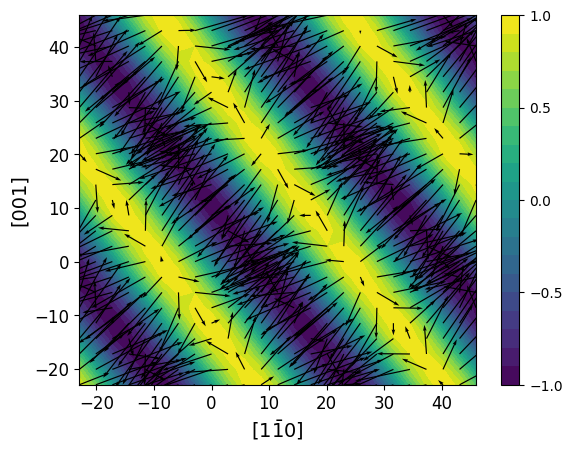

NameError: name 'B4xyz' is not defined

In [ ]:
Plot_Spins(doubleq2,2,-np.pi/4,0)

In [ ]:
def Spin2D_2qsym(param,w,r,t,nmax,th,ph):
  Qs = param[:6]
  sx, sy, sz = np.split(param[6:],3)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sya = sy[:L]; syb = np.append(0,sy[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])
  e = indexes2(nmax)[0]
  #S_x = sxa[0]
  #S_y = sya[0]
  #S_z = sza[0]
  S0 = np.array([sxa[0],sya[0],sza[0]])
  Rot_matrix = np.transpose(np.array([[np.cos(ph)*np.cos(th),-np.sin(ph),np.cos(ph)*np.sin(th)]
  ,[np.sin(ph)*np.cos(th),np.cos(ph),np.sin(ph)*np.sin(th)],
   [-np.sin(th),0,np.cos(th)]]))
  #Nv = np.dot(Rot_matrix,np.array([w,r,t]))
  W = w#Nv[0]
  R = r#Nv[1]
  T = t#Nv[2]
  #print(Rot_matrix)
  #print(np.transpose(Rot_matrix))

  S0rot = np.dot(Rot_matrix,S0)
  S_x = S0rot[0]
  S_y = S0rot[1]
  S_z = S0rot[2]

  for i in range(1,len(e)):
    Sa = np.dot(Rot_matrix,[sxa[i],sya[i],sza[i]])
    #print(Sa)
    SXa = Sa[0]
    SYa = Sa[1]
    SZa = Sa[2]
    Sb = np.dot(Rot_matrix,[sxb[i],syb[i],szb[i]])
    SXb = Sb[0]
    SYb = Sb[1]
    SZb = Sb[2]

    Q_x = e[i][0]*Qs[0] + e[i][1]*Qs[3]
    Q_y = e[i][0]*Qs[1] + e[i][1]*Qs[4]
    Q_z = e[i][0]*Qs[2] + e[i][1]*Qs[5]

    qx,qy,qz = np.dot(Rot_matrix,np.array([Q_x,Q_y,Q_z]))


    S_x += (2*SXa*cos(qx*W + qy*R + qz*T)
          - 2*SXb*sin(qx*W + qy*R + qz*T))
    S_y += (2*SYa*cos(qx*W + qy*R + qz*T)
          - 2*SYb*sin(qx*W + qy*R + qz*T))
    S_z += (2*SZa*cos(qx*W + qy*R + qz*T)
          - 2*SZb*sin(qx*W + qy*R + qz*T))
  return S_x, S_y, S_z

In [ ]:
x,y,z = symbols("x y z")
Mvec = np.array(Spin2D_2qsym(output2q, x, y, z, 2, 0, -np.pi/2))
Mderx = []
Mdery = []
for i in range(len(Mvec)):
  Mderx.append(diff(Mvec[i],x))
  Mdery.append(diff(Mvec[i],y))
topchden = np.dot(Mvec,np.cross(Mderx,Mdery))
topq = lambdify([x,y,z],topchden)

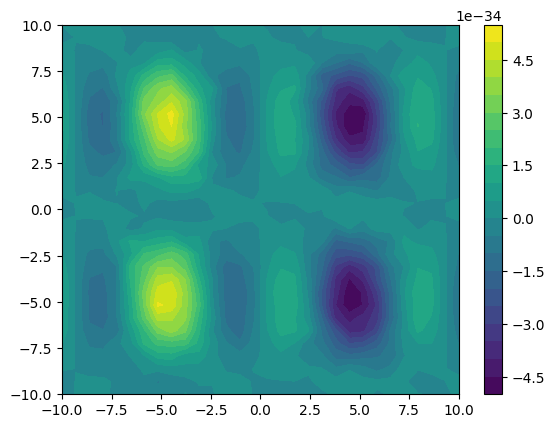

In [ ]:
U,V = np.meshgrid(np.linspace(-10, 10, 30),np.linspace(-10, 10, 30))

Topn = []
for i in range(30):
  topn = []
  for j in range(30):
    topn.append(topq(0,U[i,j],V[i,j]))
  Topn.append(topn)
contour = plt.contourf(U,V,Topn,levels = 20,)#cmap = "summer"
plt.colorbar(contour)
plt.xlim(-10, 10)
plt.ylim(-10, 10)

plt.show()

In [ ]:
dqHT = []
Temp = np.linspace(1.2,0.7,20)
for i in range(len(Temp)):
  res = minimize(energy2, x0 = dom11, method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5,
          0.00225, 0.00225, 0.00225, lamb, com2, cod2, Temp[i], T, b_l), jac = der2)
  output = res.x
  dqHT.append(output)
  print(output)


[ 1.26842228e-01  1.26842216e-01  1.27264160e-01 -1.13076550e-01
 -1.13076544e-01  1.40790959e-01  5.09008607e-02  2.43961591e-02
  6.94747606e-05 -1.59541927e-01 -5.91027261e-04 -8.91702800e-04
 -7.43339238e-05 -1.23744101e-04 -1.92375386e-06  1.19599790e-04
 -3.80918633e-06  1.56880322e-03  5.10118815e-04  2.43502435e-02
 -3.81634580e-04 -2.73503795e-01  3.83145953e-03  5.08960422e-04
  6.62199176e-05  2.31115643e-04 -2.81952130e-06 -8.57049822e-05
 -4.10449920e-06 -7.68969649e-04  2.53682729e-04  5.09008614e-02
  2.43503430e-02 -7.12079583e-05 -1.59539374e-01  3.83372959e-03
  8.91336655e-04 -7.37198255e-05  2.30182784e-04  4.18716952e-06
 -8.55871929e-05  4.86793676e-06 -7.69788723e-04 -5.08312664e-04
  2.43962447e-02 -3.78782650e-04  2.73502383e-01 -5.89855657e-04
  5.07986394e-04 -6.58335364e-05 -1.23373110e-04 -1.17825732e-06
  1.18799992e-04 -2.61357373e-06  1.56735518e-03  2.53596125e-04
  5.15581435e-02  2.52174936e-02  1.73953374e-06  3.14163860e-01
 -2.16922987e-03  3.57876

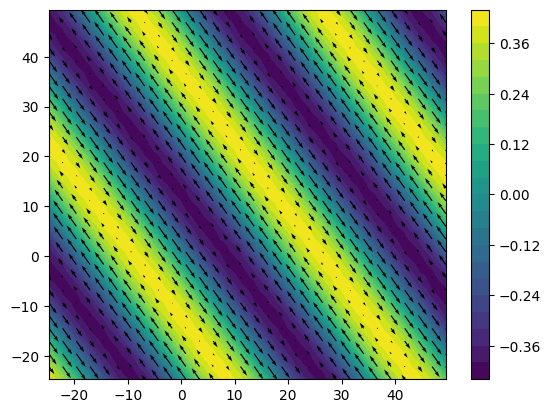

(np.float64(0.17516518073868317),
 'max error = 0.41854198280189053, min error = 0.4185074564896212')

In [ ]:
Plot_Spins(dqHT[9],2,-np.pi/4,0)

Text(0, 0.5, '$A_1^2$')

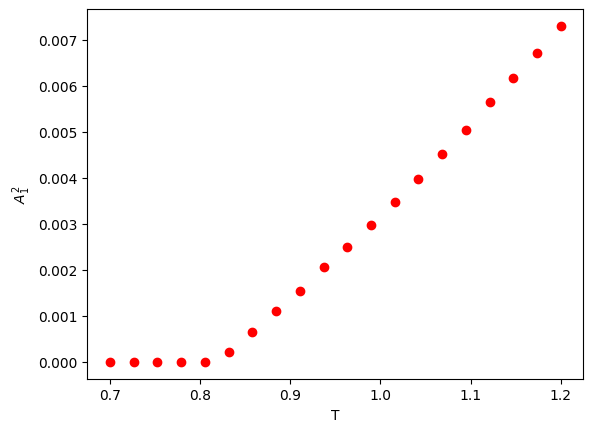

In [ ]:
ampT = []
for i in range(len(dqHT)):
  dq = input_arrays2(np.zeros((6,5,3)),dqHT[:][i],2)
  ampT.append(np.linalg.norm(2*np.array([dq[0,0,1],dq[2,0,1],dq[4,0,1]])))
ampT
#y = (0.03**2-H[:-1])**1/2
#plt.scatter(H[:-1],y)
plt.scatter(Temp[:len(dqHT)][:],np.array(ampT)[:]**2,color = "red")
plt.xlabel("T")
plt.ylabel("$A_1^2$")
#x = np.linspace(0.6,1)
#y =  0.01727221*x -0.0130356
#plt.plot(x,y)

In [ ]:
def curv(x,a,b):
  return a*x + b

In [ ]:
from scipy.optimize import curve_fit


pa, pa_co = curve_fit(curv,Temp[:15],np.array(ampT[:15])**2)
pa

NameError: name 'curv' is not defined

In [ ]:
Temp[5]

np.float64(1.068421052631579)

In [ ]:
-pa[1]/pa[0]

np.float64(0.8289109541246611)

In [ ]:
Tferro = 1 - 0.5*np.array([np.float64(-0.02419618855387476),
 np.float64(-0.023017118525057313),
 np.float64(-0.019495511426820093),
 np.float64(-0.013715126742407279),
 np.float64(-0.005489112537933213),
 np.float64(0.004987180005478211),
 np.float64(0.017763294145970943),
 np.float64(0.032663910542574545),
 np.float64(0.04988803256152328),
 np.float64(0.06926258039205889),
 np.float64(0.09060895801576176),
 np.float64(0.11391250350708454),
 np.float64(0.13732477966532178),
 np.float64(0.16662406592723356),
 np.float64(0.19259283866213595),
 np.float64(0.2186625540165241),
 np.float64(0.2574945412336061),
 np.float64(0.2922064999263622),
 np.float64(0.32831333745601254),
 np.float64(0.3655475101772185),
 np.float64(0.4037386279944128),
 np.float64(0.4338551392028635),
 np.float64(0.4809887197815677),
 np.float64(0.5227773951027666),
 np.float64(0.5589158852680691),
 np.float64(0.6021555308905457),
 np.float64(0.6533179139086641),
 np.float64(0.6800992985672802),
 np.float64(0.7112354243249829),
 np.float64(0.7701012519564775)])

In [ ]:
Tferro

array([1.01209809, 1.01150856, 1.00974776, 1.00685756, 1.00274456,
       0.99750641, 0.99111835, 0.98366804, 0.97505598, 0.96536871,
       0.95469552, 0.94304375, 0.93133761, 0.91668797, 0.90370358,
       0.89066872, 0.87125273, 0.85389675, 0.83584333, 0.81722624,
       0.79813069, 0.78307243, 0.75950564, 0.7386113 , 0.72054206,
       0.69892223, 0.67334104, 0.65995035, 0.64438229, 0.61494937])

In [ ]:
from scipy.interpolate import CubicSpline

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4006/1526372375.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("H $\parallel$ [111]", size = 14)


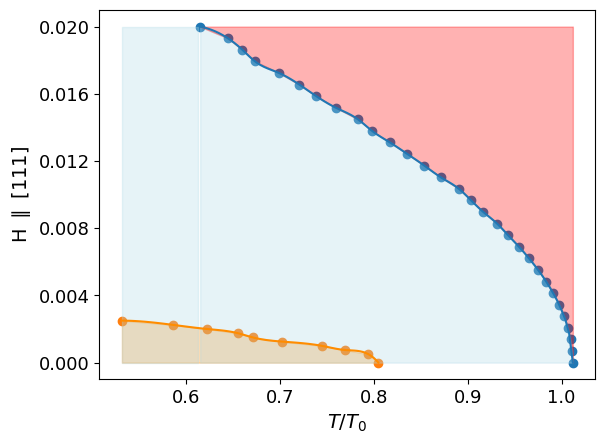

In [ ]:
from matplotlib.ticker import MultipleLocator
Temperature = 1 - 0.5*np.array([0.39036023801488834,0.4113854542072495,0.46123656571415445,0.5109452501781923,0.5947368421052631,0.6578947368421053,0.6894736842105263,0.7547149541883474,0.8289109541246611,0.9368421052631579])
field = [0,0.0005,0.00075,0.001,0.00125,0.0015,0.00175,0.002,0.00225,0.0025]
plt.scatter(Tferro,np.linspace(0.00,0.02,30))
plt.scatter(np.flip(Temperature),np.flip(field))
#plt.plot(Tferro,np.linspace(0.00,0.02,30))
#plt.plot(Temperature,field)
cs = CubicSpline(np.flip(Temperature), np.flip(field))
xdata = np.linspace(np.flip(Temperature)[0], np.flip(Temperature)[-1],100)
ydata = cs(xdata)
plt.plot(xdata,ydata, color = "darkorange")
cs2 = CubicSpline(np.flip(Tferro), np.flip(np.linspace(0.00,0.02,30)))
xdata2 = np.linspace(np.flip(Tferro)[0], np.flip(Tferro)[-1],100)
ydata2 = cs2(xdata2)
plt.plot(xdata2,ydata2)

plt.fill_between(Temperature, np.zeros(len(Temperature)), field, where=(np.zeros(len(Temperature)) <= field), color='darkorange', alpha=0.3,
                 interpolate=True)
plt.fill_between(Tferro, np.zeros(30),np.linspace(0.00,0.02,30), where=(np.zeros(30) < np.linspace(0.00,0.02,30)), color='lightblue', alpha=0.3,interpolate=True)
plt.fill_between(Tferro, 0.02*np.ones(30),np.linspace(0.00,0.02,30), where=(0.02*np.ones(30) > np.linspace(0.00,0.02,30)), color='red', alpha=0.3,interpolate=True)
plt.fill_between([Temperature[-1],Tferro[-1] - 0.002], 0.02*np.ones(2), np.zeros(2), where=(0.02*np.ones(2) > np.zeros(2)), color='lightblue', alpha=0.3,interpolate=True)
plt.xlabel("$T/T_0$", size = 14)
plt.ylabel("H $\parallel$ [111]", size = 14)
plt.tick_params(axis = "x", labelsize = 13)
plt.tick_params(axis = "y", labelsize = 13)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.004))
plt.show()

In [ ]:
np.flip(Temperature)[0]

np.float64(0.531578947368421)

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4006/3790765512.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("H $\parallel$ [111]", size = 14)


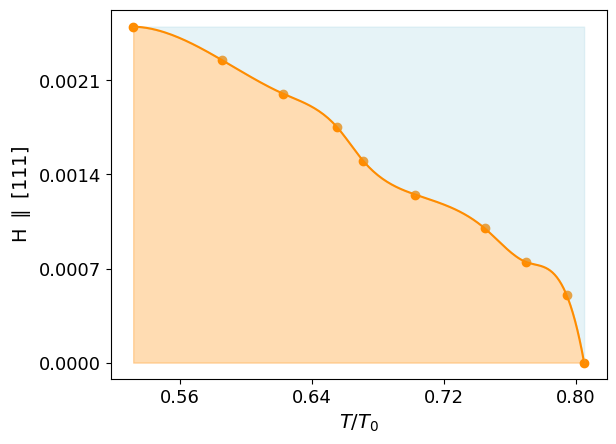

In [ ]:
plt.scatter(Temperature,field, color = "darkorange")
#plt.plot(Temperature,field, color = "darkorange")
plt.tick_params(axis = "x", labelsize = 11)
plt.tick_params(axis = "y", labelsize = 11)
cs = CubicSpline(np.flip(Temperature), np.flip(field))
xdata = np.linspace(np.flip(Temperature)[0], np.flip(Temperature)[-1],200)
ydat = cs(xdata)
plt.plot(xdata,ydat, color = "darkorange")
plt.fill_between(xdata, np.zeros(len(xdata)), ydat, where=(np.zeros(len(xdata)) <= ydat), color='darkorange', alpha=0.3,
                 interpolate=True)
plt.fill_between(xdata, ydat, 0.0025*np.ones(len(xdata)), where=(ydat <= 0.0025*np.ones(len(xdata))), color='lightblue', alpha=0.3,
                 interpolate=True)
plt.xlabel("$T/T_0$", size = 14)
plt.ylabel("H $\parallel$ [111]", size = 14)
plt.tick_params(axis = "x", labelsize = 13)
plt.tick_params(axis = "y", labelsize = 13)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.08))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.0007))

H = 0.006, (Tc - T) = 0.06242120878763223
H = 0.009, (Tc - T) = 0.17093156899578063
H = 0.012, (Tc - T) = 0.3102069456084239
H = 0.017, (Tc - T) = 0.5994595741366879
H = 0.020, (Tc - T) = 0.7978184906943206


Text(0, 0.5, 'H')

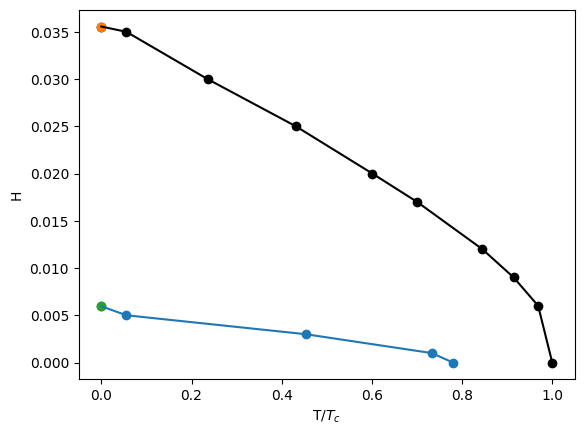

In [ ]:
H1 = [0,0.006,0.009,0.012,0.017,0.02,0.025,0.03,0.035,0.03556003875703686]
H2 = [0,0.001,0.003,0.005,0.005953186204516894]
T1 = 1 - 0.5*np.array([0,0.06242120878763223,0.17093156899578063,0.3102069456084239,0.5994595741366879,0.7978184906943206,1.1370731195164556,1.5290514286073191,1.8888885243588354,2])
T2 = 1 - 0.5*np.array([0.44044540342598343,0.5343370941233708,1.0943548155369796,1.8887581117867602,2])
plt.scatter(T1, H1, color = "black")
plt.plot(T1, H1, "black")
plt.scatter(T2,H2)
plt.plot(T2,H2)
plt.scatter(0,0.03556003875703686)
plt.scatter(0,0.005953186204516894)
plt.xlabel("T/$T_c$")
plt.ylabel("H")

In [ ]:
T2

array([0.7797773 , 0.73283145, 0.45282259, 0.05562094, 0.        ])

In [ ]:
Hconf = np.array([ 1.26993418e-01,  1.27006211e-01,  1.27000760e-01, -1.74451530e-02,
       -2.35737713e-02, -1.14759087e-01,  2.16743932e-01, -1.00438299e-05,
        1.18907242e-05, -1.69510587e-01, -2.46695591e-05,  1.03331433e-05,
       -1.18146385e-05, -8.81537890e-07, -1.20925665e-06,  2.86012180e-07,
       -2.45363358e-07,  1.67790933e-06,  4.64833253e-07,  3.01430632e-05,
       -2.31583441e-06, -3.38372337e-01,  1.58632350e-05,  9.31398981e-06,
        1.48650351e-05, -7.89316050e-08,  7.62487133e-07, -6.62877863e-07,
        1.92867493e-08,  2.85922914e-06, -5.87829124e-07,  2.16789543e-01,
       -2.51081145e-05,  8.26021753e-06, -2.08262013e-01, -7.40098220e-06,
        1.10967291e-05, -9.72486136e-06,  1.19408909e-06,  9.08124325e-10,
        3.82425824e-07, -2.05001959e-07, -8.88617247e-07,  2.04728173e-07,
        1.55983211e-05,  5.92256631e-06,  3.15947157e-01,  2.47740319e-05,
        1.88561156e-06, -2.13345632e-05,  1.60748639e-07,  3.66845956e-07,
       -4.38104965e-07, -2.00380590e-07, -4.05663294e-06,  1.91037770e-07,
        2.16768148e-01, -8.48150962e-06,  2.20971534e-06,  3.77770651e-01,
       -8.64929358e-06,  5.49104780e-06,  2.23813424e-05,  3.59239929e-07,
       -9.48118735e-07,  1.36508945e-07, -3.20169713e-08,  5.86690195e-06,
       -7.46553903e-08,  1.12871520e-05, -1.10674325e-06,  2.23493557e-02,
        6.33416501e-06,  4.50425857e-06,  2.62151509e-06, -1.75200515e-06,
       -4.83777530e-07, -4.61007618e-07, -5.34659821e-08, -1.95197290e-06,
       -2.75238000e-07])

In [ ]:
nmax = 2
lamb = 100 #symbols("L")
J = 1
K = -0.02 #-0.0027
alpha1 = 8 #7.2
alpha2 = 7 #7.2
alpha3 = 0.7
alpha4 = 0
alpha5 = 0.00
a_l = 0
T = 0
b_l = 0

Hx = 0.00
Hy = 0.00
Hz = 0.00

In [ ]:
dqH = []
H = np.linspace(0.0046,0.03,20)
for i in range(len(H)):
  res = minimize(energy2, x0 = Hconf, method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha4, alpha5,
          H[i], H[i], H[i], lamb, com2, cod2, a_l, T, b_l), jac = der2)
  output = res.x
  dqH.append(output)
  print(output)


[ 1.27000865e-01  1.26999454e-01  1.27000186e-01 -1.74451534e-02
 -2.35737721e-02 -1.14759100e-01  2.15368011e-01  1.88332040e-06
 -8.11531855e-07 -1.69688601e-01  5.13412692e-06  1.81429054e-06
 -1.28565473e-05  4.38602472e-08  1.01154010e-07 -7.79560613e-09
 -2.29171026e-08  3.23537208e-07  4.33233804e-09 -5.96331839e-06
 -3.39028030e-07 -3.38701476e-01 -3.81218502e-06 -7.22048606e-09
  1.73947396e-05  3.05406306e-08  6.20869063e-07  1.12314378e-07
 -3.89304109e-09 -1.05888168e-06 -8.14785724e-08  2.15362614e-01
  5.13978946e-06 -1.19644134e-06 -2.08482495e-01  2.01705241e-06
  1.87777076e-06 -8.54405787e-06 -2.46820538e-07  3.99763326e-07
 -3.57032283e-08 -3.07622077e-08  9.01567065e-07  1.95170440e-09
 -3.00596207e-06  7.41840826e-07  3.16309324e-01 -4.87529662e-06
  1.32472404e-06 -1.96117080e-05  3.64526071e-08 -6.01920129e-07
  1.01168659e-07  1.34742037e-08  6.66254009e-07  1.11145187e-07
  2.15365399e-01  7.02116083e-07 -1.86652960e-06  3.78170451e-01
  2.80011757e-06  3.18392

KeyboardInterrupt: 

In [ ]:
dqH[-1]

array([ 1.26993418e-01,  1.27006211e-01,  1.27000760e-01, -1.74451530e-02,
       -2.35737713e-02, -1.14759087e-01,  2.16743932e-01, -1.00438299e-05,
        1.18907242e-05, -1.69510587e-01, -2.46695591e-05,  1.03331433e-05,
       -1.18146385e-05, -8.81537890e-07, -1.20925665e-06,  2.86012180e-07,
       -2.45363358e-07,  1.67790933e-06,  4.64833253e-07,  3.01430632e-05,
       -2.31583441e-06, -3.38372337e-01,  1.58632350e-05,  9.31398981e-06,
        1.48650351e-05, -7.89316050e-08,  7.62487133e-07, -6.62877863e-07,
        1.92867493e-08,  2.85922914e-06, -5.87829124e-07,  2.16789543e-01,
       -2.51081145e-05,  8.26021753e-06, -2.08262013e-01, -7.40098220e-06,
        1.10967291e-05, -9.72486136e-06,  1.19408909e-06,  9.08124325e-10,
        3.82425824e-07, -2.05001959e-07, -8.88617247e-07,  2.04728173e-07,
        1.55983211e-05,  5.92256631e-06,  3.15947157e-01,  2.47740319e-05,
        1.88561156e-06, -2.13345632e-05,  1.60748639e-07,  3.66845956e-07,
       -4.38104965e-07, -

In [ ]:
np.linspace(0.00,0.03,20)

array([0.        , 0.00157895, 0.00315789, 0.00473684, 0.00631579,
       0.00789474, 0.00947368, 0.01105263, 0.01263158, 0.01421053,
       0.01578947, 0.01736842, 0.01894737, 0.02052632, 0.02210526,
       0.02368421, 0.02526316, 0.02684211, 0.02842105, 0.03      ])

Text(0, 0.5, 'A2')

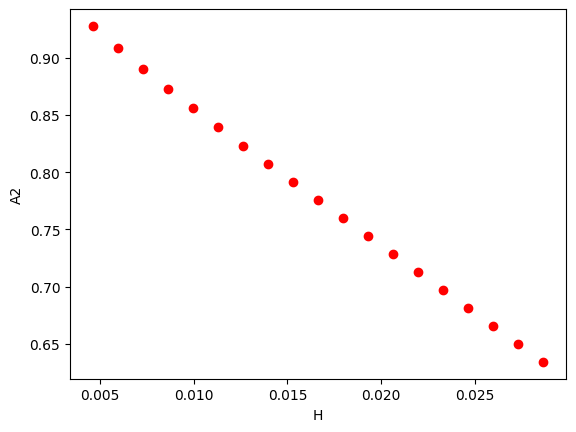

In [ ]:
amp = []
for i in range(len(dqH)):
  dq = input_arrays2(np.zeros((6,5,3)),dqH[:][i],2)
  amp.append(np.linalg.norm(2*np.array([dq[0,1,0],dq[2,1,0],dq[4,1,0]])))
amp
#y = (0.03**2-H[:-1])**1/2
#plt.scatter(H[:-1],y)
plt.scatter(H[:len(dqH)],np.array(amp),color = "red")
plt.xlabel("H")
plt.ylabel("A2")

In [ ]:
H[:len(dqH)][-1]

np.float64(0.004666666666666666)

In [ ]:
dq = input_arrays2(np.zeros((6,5,3)),dqH[-1],2)
np.linalg.norm(2*np.array([dq[0,1,0],dq[2,1,0],dq[4,1,0]]))

np.float64(0.926968326445456)

In [ ]:
np.array(amp)**2

array([3.19127783e-02, 3.14795946e-02, 3.00909979e-02, 2.77397136e-02,
       2.43090072e-02, 1.96422435e-02, 1.32993039e-02, 5.24879963e-03,
       9.53911902e-09])

In [ ]:
1/(2*15)

0.03333333333333333

In [ ]:
0.0035/0.025

0.13999999999999999

In [ ]:
from scipy.optimize import curve_fit


pa, pa_co = curve_fit(curv,H[:-1],np.array(amp[:])**2)
pa

array([-18.75431531,   0.92385847])

In [ ]:
Hc1 = pa[1]/pa[0]
Hc1

np.float64(-0.04926111425287429)

In [ ]:
H[-3]

np.float64(0.006222222222222223)

K = -0.005, alpha3 = 0.03
alpha2 = 10, Hc1 = 0.0046122564025905645
alpha2 = 5, Hc1 = 0.005624519564653574
alpha2 = 1, Hc1 = 0.007678459645808637
alpha2 = 0.7, Hc1 = 0.008030181680560288

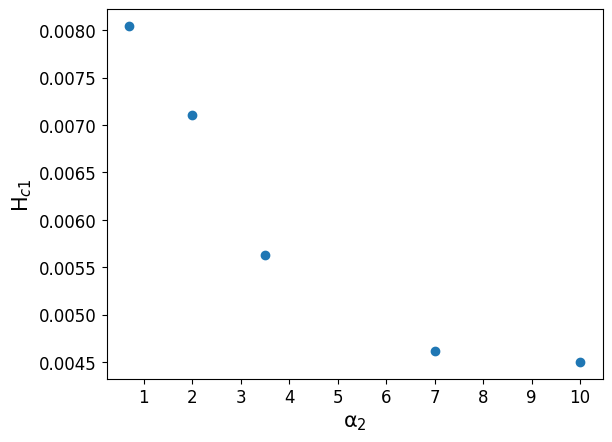

In [ ]:
a2a = [10,7,3.5,2,0.7]
Hc1a = [0.004500578605690403,0.0046122564025905645,0.005624519564653574,0.00710388013897273,0.008044752183381451]
plt.ylabel("H$_{c1}$", size = 15)
plt.xlabel("$⍺_2$", size = 15)
plt.scatter(a2a,Hc1a)
plt.tick_params(axis = "x", labelsize = 12)
plt.tick_params(axis = "y", labelsize = 12)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.0005))

In [ ]:
Ka = [-0.005,]

Text(0, 0.5, '$A_2^2$')

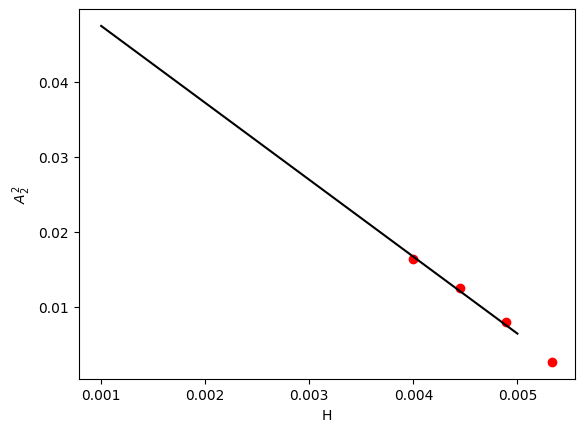

In [ ]:
plt.scatter(H[:4],np.array(amp[:4])**2,color = "red")
x = np.linspace(0.001,0.005,100)
y = -pa[0]*x + pa[1]
plt.plot(x,y,color = "black")
plt.xlabel("H")
plt.ylabel("$A_2^2$")

In [ ]:
dqH2 = [dqH[-1]]
H2 = np.linspace(0.008,0.03,10)
for i in range(len(H)):
  res = minimize(energy2, x0 = dqH2[i], method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha5,
          H2[i], H2[i], H2[i], lamb, com2, cod2), jac = der2)
  output = res.x
  dqH2.append(output)
  print(output)


[ 1.42290840e-01  1.42289143e-01  1.42238284e-01 -1.45214357e-01
 -1.45227769e-01  1.26671644e-01  1.43238510e-01  1.61762848e-02
  4.82152938e-05 -1.98010944e-01 -1.15358849e-03 -4.48206438e-04
 -7.93303051e-06 -5.00070553e-05 -1.99412558e-05  2.58506690e-05
 -2.78283481e-07  3.23545751e-04  9.44810107e-05  1.58946780e-02
 -5.88307598e-05 -3.41890949e-01  8.43544242e-03  2.29134000e-04
 -1.29655710e-05  1.25584524e-04  9.92283940e-06 -1.02049378e-05
 -3.71962584e-07 -1.84750782e-04  5.51681527e-05  1.43238287e-01
  1.56916564e-02 -4.65780770e-05 -1.98062970e-01  8.46223016e-03
  4.41950420e-04 -7.94106927e-06  1.26022276e-04  1.99220311e-05
 -1.06000888e-05  3.09516037e-07 -1.89843261e-04 -9.59238008e-05
  1.63795476e-02 -5.93876787e-05  3.41864017e-01 -1.05763721e-03
  2.40661155e-04  1.27596944e-05 -4.94337975e-05  1.01494651e-05
  2.58178017e-05 -3.53218141e-07  3.21374699e-04  5.26768385e-05
  1.43692211e-01  1.57414439e-02  1.16534580e-06  3.94113634e-01
 -4.54865013e-03  6.73567

Text(0, 0.5, 'A1')

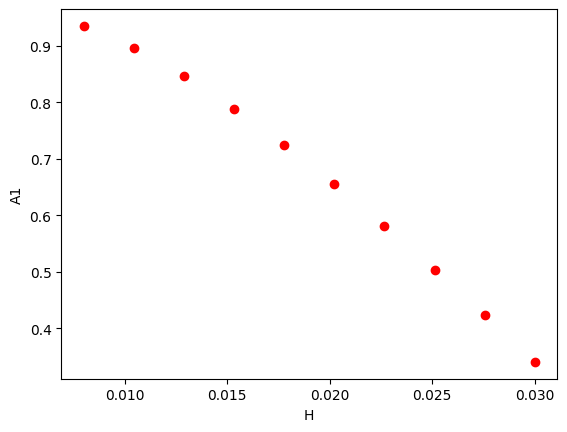

In [ ]:
amp1 = []
H2 = np.linspace(0.008,0.03,10)
for i in range(len(H2)):
  dq1 = input_arrays2(np.zeros((6,5,3)),dqH2[1:][i],2)
  amp1.append(np.linalg.norm(2*np.array([dq1[0,1,0],dq1[2,1,0],dq1[4,1,0]])))
amp1
plt.scatter(H2,np.array(amp1)**2,color = "red")
plt.xlabel("H")
plt.ylabel("A1")

In [ ]:
pa2, pa_co2 = curve_fit(curv,H2[-3:],np.array(amp1[-3:])**2)
pa2

array([33.29166291,  1.33941669])

Text(0, 0.5, '$A_2^2$')

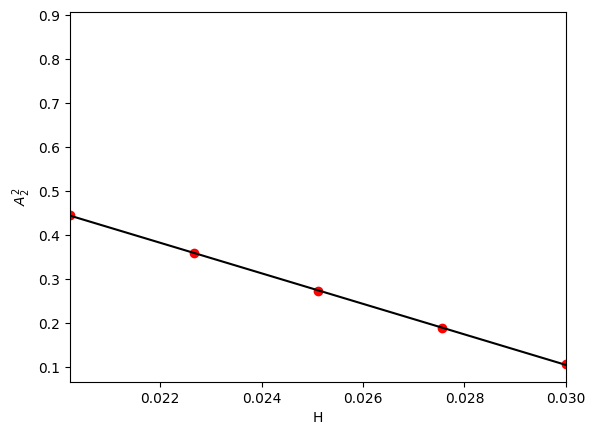

In [ ]:
plt.scatter(H2[-5:],np.array(amp1[-5:])**2,color = "red")
plt.xlim(H2[-5],H2[-1])
y = -pa2[0]*H2 + pa2[1]
plt.plot(H2,y,color = "black")
plt.xlabel("H")
plt.ylabel("$A_2^2$")

In [ ]:
Hc2 = pa2[1]/pa2[0]
Hc2

np.float64(0.04023279630094697)

In [ ]:
Hc1/Hc2

np.float64(0.23060071400005142)

In [ ]:
alpa2ar = [0.7,2,3.5,7,10]
Hc2ar = [0.04304451148102419,0.04108977536375398,0.039134993494491045,0.03547668317812106,0.033040962607265786]
Rat = [0.18689379683000729,0.17288680884926882,0.16030073686164334,0.1418741680477153,0.1362120910091377]

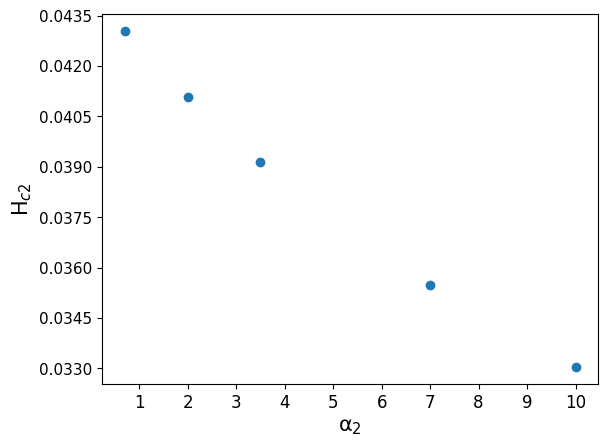

In [ ]:
plt.scatter(alpa2ar,Hc2ar)
plt.ylabel("H$_{c2}$", size = 15)
plt.xlabel("$⍺_2$", size = 15)
plt.tick_params(axis = "x", labelsize = 12)
plt.tick_params(axis = "y", labelsize = 11)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.0015))


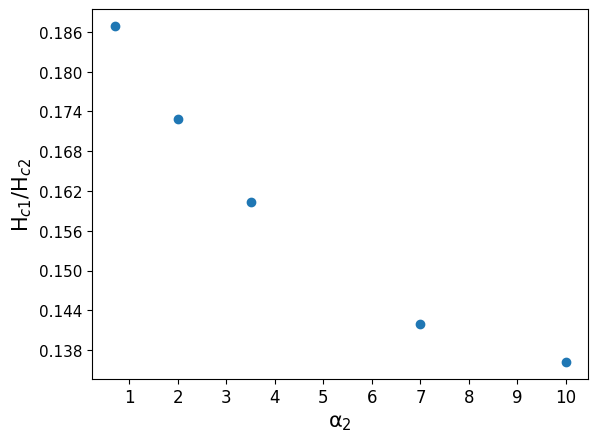

In [ ]:
plt.scatter(alpa2ar,Rat)
plt.ylabel("H$_{c1}$/H$_{c2}$", size = 15)
plt.xlabel("$⍺_2$", size = 15)
plt.tick_params(axis = "x", labelsize = 12)
plt.tick_params(axis = "y", labelsize = 11)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.006))

K = -0.009
alpha1 = 8
alpha2 = 7
alpha3 = 0.2
Hc1 = 0.005543, Hc2 = 0.04101, Hc2/Hc1 = 0.13515

alpha2 = 15, Hc1 = 0.003865, Hc2 = 0.03571, Hc2/Hc1 = 0.1082

In [ ]:
nmax = 2
lamb = 100 #symbols("L")
J = 1
K = -0.008 #-0.0027
alpha1 = 8 #7.2
alpha2 = 7 #7.2
alpha3 = 0.5
alpha4 = 0.0
alpha5 = 0.0
a_l = 0
T = 0
b_l = 0

Hx = 0.00
Hy = 0.00
Hz = 0.00

In [ ]:
dq = []
alpha3ar = np.arange(300,310,1)
for i in range(len(alpha3ar)):
  res = minimize(energy2, x0 = dom11, method = "BFGS", args = (nmax, J, -0.003, alpha1, alpha2, alpha3ar[i], alpha5,
          Hx, Hy, Hz, lamb, com2, cod2), jac = der2)
  output = res.x
  dq.append(output)

  print(output)

[ 1.26962218e-01  1.26964339e-01  1.27073503e-01 -8.90114237e-02
 -8.38153113e-02  1.68080213e-01  0.00000000e+00  1.07008669e-02
  0.00000000e+00 -2.03822117e-01  0.00000000e+00 -9.49443000e-05
  0.00000000e+00 -5.22257177e-06  0.00000000e+00  9.89104635e-05
  0.00000000e+00  0.00000000e+00  1.41331030e-04  1.04752709e-02
  0.00000000e+00 -3.53506450e-01  0.00000000e+00  2.02572713e-04
  0.00000000e+00  1.46845163e-04  0.00000000e+00 -7.04801845e-05
  0.00000000e+00  0.00000000e+00 -1.27502685e-04  0.00000000e+00
  1.06709956e-02  0.00000000e+00 -2.04410778e-01  0.00000000e+00
  9.66491092e-05  0.00000000e+00  1.45892371e-04  0.00000000e+00
 -6.58801251e-05  0.00000000e+00  0.00000000e+00 -1.53421882e-04
  1.05175216e-02  0.00000000e+00  3.53162421e-01  0.00000000e+00
  1.99260328e-04  0.00000000e+00 -1.18272876e-06  0.00000000e+00
  1.03907414e-04  0.00000000e+00  0.00000000e+00 -1.21815424e-04
  0.00000000e+00  1.09772929e-02  0.00000000e+00  4.07877736e-01
  0.00000000e+00 -1.97914

KeyboardInterrupt: 

Text(0, 0.5, 'A2')

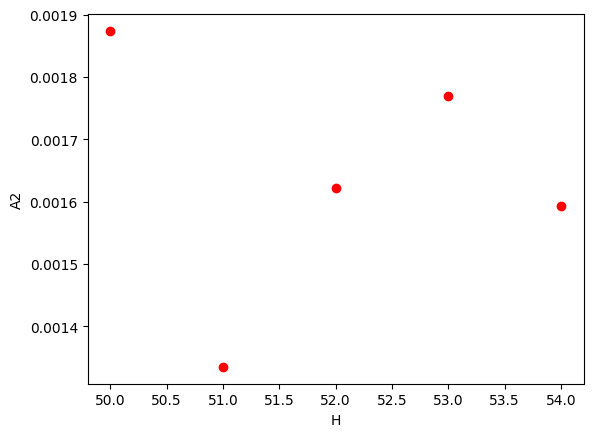

In [ ]:
amp = []
for i in range(len(dq)):
  dq2 = input_arrays2(np.zeros((6,5,3)),dq[i],2)
  amp.append(np.linalg.norm(2*np.array([dq2[0,0,1],dq2[2,0,1],dq2[4,0,1]])))
amp

plt.scatter(alpha3ar[:len(dq)],np.array(amp)**2,color = "red")
plt.xlabel("H")
plt.ylabel("A2")

K = -0.003, alpha3 = 0.07
K = -0.005, alpha3 = 0.09
K = -0.007, alpha3 = 0.1
K = -0.009, alpha3 = 0.1
K = -0.01, alpha3 = 0.03
K = -0.02, alpha3 = 0.06
K = -0.03, alpha3 = 0.06
K = -0.04, alpha3 = 0.07
K = -0.05, alpha3 = 0.08
K = -0.07, alpha3 = 0.09
K = -0.1, alpha3 = 0.1

Text(0, 0.5, 'alpha3')

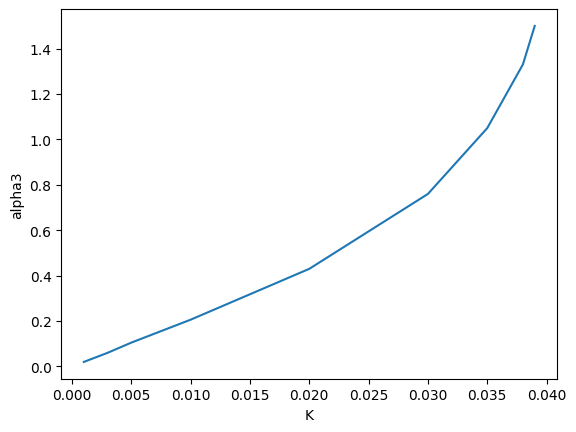

In [ ]:
Ka = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.035,0.038,0.039]
a3a = [0.02,0.04,0.06,0.105,0.206,0.43,0.76,1.05,1.33,1.5]
plt.plot(Ka,a3a)
plt.xlabel("K")
plt.ylabel("alpha3")

In [ ]:
dqangle = []
EN = np.zeros(len(Kar))
for j in range(len(Kar)):
  EN[j] = energy2(dq[j],nmax, J, -0.003, alpha1, alpha2, 300, alpha5,
        Hx, Hy, Hz, lamb, com2, cod2)
  dqangle.append(np.arccos(np.dot(dq[j][3:6]/np.linalg.norm(dq[j][3:6]),1/np.sqrt(3)*np.array([1,1,1])))/np.pi*180)

In [ ]:
in_ar2q3 = input_arrays2(np.zeros((6,7,4)),in_arrays2q1,2)
in_arrays2q3 = np.concatenate((in_arrays2q1[:6],generate_param2(in_ar2q3,3)))
in_arrays2q3

array([ 0.13      ,  0.13      ,  0.13      , -0.13      , -0.13      ,
        0.13      ,  0.        ,  0.10606602,  0.        ,  0.        ,
       -0.35355339,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.06123724,  0.        ,  0.        ,  0.20412415,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.10606602,  0.        ,  0.        ,  0.35355339,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [ ]:
res2q = minimize(energy2, x0 = in_arrays2q3, method = "BFGS", jac = der2)
output2q = res2q.x
print(res2q)
output2q

ValueError: operands could not be broadcast together with shapes (13,) (25,) 

In [ ]:
output2q3 = np.array([ 1.26956642e-01,  1.26961099e-01,  1.27073630e-01, -1.25788003e-01,
       -1.25796149e-01,  1.25910320e-01,  0.00000000e+00,  3.46165106e-02,
        0.00000000e+00, -2.06516048e-07, -3.54120377e-01,  0.00000000e+00,
       -8.24163207e-06,  0.00000000e+00,  0.00000000e+00, -4.41151766e-05,
        0.00000000e+00, -2.05782308e-08,  2.74052914e-06,  0.00000000e+00,
       -2.22956344e-06,  0.00000000e+00,  0.00000000e+00,  5.44521291e-07,
        0.00000000e+00,  5.63458622e-06,  0.00000000e+00,  2.05583613e-08,
        0.00000000e+00,  3.94079459e-04,  0.00000000e+00, -1.98786892e-02,
        0.00000000e+00,  2.23290598e-05,  2.09453801e-01,  0.00000000e+00,
       -1.39092339e-03,  0.00000000e+00,  0.00000000e+00, -3.20344268e-05,
        0.00000000e+00, -2.21730704e-07,  8.20581656e-05,  0.00000000e+00,
       -3.00626342e-08,  0.00000000e+00,  0.00000000e+00,  4.08873258e-07,
        0.00000000e+00,  2.04560331e-05,  0.00000000e+00, -2.26216946e-08,
        0.00000000e+00, -2.23863019e-04,  0.00000000e+00,  0.00000000e+00,
        3.46283474e-02,  0.00000000e+00, -2.43661113e-08,  3.53970999e-01,
        0.00000000e+00, -1.21261196e-03,  0.00000000e+00,  0.00000000e+00,
        5.05723691e-06,  0.00000000e+00,  2.68266453e-08, -2.67617183e-06,
        0.00000000e+00, -1.13359534e-06,  0.00000000e+00,  0.00000000e+00,
        6.23059856e-07,  0.00000000e+00, -1.47657711e-05,  0.00000000e+00,
       -2.04413973e-08,  0.00000000e+00,  5.70253000e-08,  0.00000000e+00,
       -1.99472585e-02,  0.00000000e+00,  2.23455227e-05,  2.09276097e-01,
        0.00000000e+00,  6.80351864e-04,  0.00000000e+00,  0.00000000e+00,
        5.46628370e-05,  0.00000000e+00, -2.29669942e-07,  8.21087744e-05,
        0.00000000e+00, -1.92338666e-06,  0.00000000e+00,  0.00000000e+00,
        2.72578513e-07,  0.00000000e+00, -1.55082018e-05,  0.00000000e+00,
       -2.29206135e-08,  0.00000000e+00,  4.52956972e-04,  0.00000000e+00,
        0.00000000e+00,  3.60030655e-02,  0.00000000e+00, -1.08635483e-07,
       -2.32993240e-04,  0.00000000e+00,  1.17746862e-03,  0.00000000e+00,
        0.00000000e+00,  2.64708988e-05,  0.00000000e+00, -5.10384781e-09,
        1.26139999e-07,  0.00000000e+00, -3.37222708e-06,  0.00000000e+00,
        0.00000000e+00,  7.24011356e-07,  0.00000000e+00,  4.27639201e-06,
        0.00000000e+00, -6.77057094e-11,  0.00000000e+00, -3.87863841e-04,
        0.00000000e+00, -2.07060579e-02,  0.00000000e+00,  2.29751891e-05,
       -4.03756173e-01,  0.00000000e+00,  6.84213412e-04,  0.00000000e+00,
        0.00000000e+00, -1.45202417e-05,  0.00000000e+00,  5.46907013e-08,
        8.47596425e-05,  0.00000000e+00, -1.95748893e-06,  0.00000000e+00,
        0.00000000e+00,  4.21032417e-07,  0.00000000e+00, -2.38180831e-06,
        0.00000000e+00,  1.52388699e-08,  0.00000000e+00, -2.25999885e-04,
        0.00000000e+00])

In [ ]:
input_arrays2(np.zeros((6,7,4)),output2q3,3)

array([[[ 0.00000000e+00,  3.46165106e-02,  0.00000000e+00,
         -2.06516048e-07],
        [-3.54120377e-01,  0.00000000e+00, -8.24163207e-06,
          0.00000000e+00],
        [ 0.00000000e+00, -4.41151766e-05,  0.00000000e+00,
         -2.05782308e-08],
        [ 2.74052914e-06,  0.00000000e+00, -2.22956344e-06,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  5.44521291e-07,
          0.00000000e+00],
        [ 0.00000000e+00,  5.63458622e-06,  0.00000000e+00,
          2.05583613e-08],
        [ 0.00000000e+00,  0.00000000e+00,  3.94079459e-04,
          0.00000000e+00]],

       [[ 0.00000000e+00, -1.98786892e-02,  0.00000000e+00,
          2.23290598e-05],
        [ 2.09453801e-01,  0.00000000e+00, -1.39092339e-03,
          0.00000000e+00],
        [ 0.00000000e+00, -3.20344268e-05,  0.00000000e+00,
         -2.21730704e-07],
        [ 8.20581656e-05,  0.00000000e+00, -3.00626342e-08,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00

In [ ]:
in_ar2q4 = input_arrays2(np.zeros((6,9,5)),output2q3,3)
in_arrays2q4 = np.concatenate((output2q3[:6],generate_param2(in_ar2q4,4)))
in_arrays2q4

array([ 1.26956642e-01,  1.26961099e-01,  1.27073630e-01, -1.25788003e-01,
       -1.25796149e-01,  1.25910320e-01,  0.00000000e+00,  3.46165106e-02,
        0.00000000e+00, -2.06516048e-07,  0.00000000e+00, -3.54120377e-01,
        0.00000000e+00, -8.24163207e-06,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -4.41151766e-05,  0.00000000e+00, -2.05782308e-08,
        0.00000000e+00,  2.74052914e-06,  0.00000000e+00, -2.22956344e-06,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.44521291e-07,  0.00000000e+00,  0.00000000e+00,  5.63458622e-06,
        0.00000000e+00,  2.05583613e-08,  0.00000000e+00,  0.00000000e+00,
        3.94079459e-04,  0.00000000e+00,  0.00000000e+00, -1.98786892e-02,
        0.00000000e+00,  2.23290598e-05,  0.00000000e+00,  2.09453801e-01,
        0.00000000e+00, -

In [ ]:
res2q = minimize(energy2, x0 = in_arrays2q4, method = "BFGS", jac = der2)
output2q = res2q.x
print(res2q)
output2q #

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.02485657498818065
        x: [ 1.270e-01  1.270e-01 ...  0.000e+00 -5.476e-08]
      nit: 14
      jac: [ 3.920e-08  4.726e-08 ...  0.000e+00 -2.380e-07]
 hess_inv: [[ 1.000e+00  5.950e-05 ...  0.000e+00  1.271e-03]
            [ 5.950e-05  1.000e+00 ...  0.000e+00  9.831e-04]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [ 1.271e-03  9.831e-04 ...  0.000e+00  9.554e-01]]
     nfev: 21
     njev: 21


array([ 1.26956494e-01,  1.26960944e-01,  1.27073697e-01, -1.25788189e-01,
       -1.25796164e-01,  1.25910127e-01,  0.00000000e+00,  3.46168153e-02,
        0.00000000e+00, -2.20854170e-07,  0.00000000e+00, -3.54120672e-01,
        0.00000000e+00, -8.01550550e-06,  0.00000000e+00,  3.76183254e-07,
        0.00000000e+00, -4.46706423e-05,  0.00000000e+00,  2.92927850e-08,
        0.00000000e+00,  3.32063622e-06,  0.00000000e+00, -1.93983162e-06,
        0.00000000e+00,  1.41124162e-09,  0.00000000e+00,  6.90072059e-06,
        0.00000000e+00, -6.31102119e-08,  0.00000000e+00,  7.52005968e-08,
        0.00000000e+00, -1.13260220e-08,  0.00000000e+00,  0.00000000e+00,
        3.61735202e-07,  0.00000000e+00,  3.04161896e-08,  8.08887428e-06,
        0.00000000e+00, -1.65423320e-09,  0.00000000e+00,  0.00000000e+00,
        3.94457481e-04,  0.00000000e+00, -4.89122203e-09, -1.98784041e-02,
        0.00000000e+00,  2.24630615e-05,  0.00000000e+00,  2.09453660e-01,
        0.00000000e+00, -

In [ ]:
output2q4 = np.array([ 1.26956494e-01,  1.26960944e-01,  1.27073697e-01, -1.25788189e-01,
       -1.25796164e-01,  1.25910127e-01,  0.00000000e+00,  3.46168153e-02,
        0.00000000e+00, -2.20854170e-07,  0.00000000e+00, -3.54120672e-01,
        0.00000000e+00, -8.01550550e-06,  0.00000000e+00,  3.76183254e-07,
        0.00000000e+00, -4.46706423e-05,  0.00000000e+00,  2.92927850e-08,
        0.00000000e+00,  3.32063622e-06,  0.00000000e+00, -1.93983162e-06,
        0.00000000e+00,  1.41124162e-09,  0.00000000e+00,  6.90072059e-06,
        0.00000000e+00, -6.31102119e-08,  0.00000000e+00,  7.52005968e-08,
        0.00000000e+00, -1.13260220e-08,  0.00000000e+00,  0.00000000e+00,
        3.61735202e-07,  0.00000000e+00,  3.04161896e-08,  8.08887428e-06,
        0.00000000e+00, -1.65423320e-09,  0.00000000e+00,  0.00000000e+00,
        3.94457481e-04,  0.00000000e+00, -4.89122203e-09, -1.98784041e-02,
        0.00000000e+00,  2.24630615e-05,  0.00000000e+00,  2.09453660e-01,
        0.00000000e+00, -1.39070951e-03,  0.00000000e+00,  2.10136410e-07,
        0.00000000e+00, -3.87855526e-05,  0.00000000e+00, -1.94799420e-07,
        0.00000000e+00,  8.22014244e-05,  0.00000000e+00,  2.28864109e-07,
        0.00000000e+00, -6.13660026e-09,  0.00000000e+00,  3.84559755e-06,
        0.00000000e+00,  3.77152438e-08,  0.00000000e+00, -3.68704251e-06,
        0.00000000e+00,  9.16189693e-08,  0.00000000e+00,  0.00000000e+00,
        3.12816428e-07,  0.00000000e+00,  1.01058317e-08,  2.19689872e-05,
        0.00000000e+00, -2.15204068e-08,  0.00000000e+00,  0.00000000e+00,
       -2.24093276e-04,  0.00000000e+00,  1.20370397e-07,  0.00000000e+00,
        3.46282449e-02,  0.00000000e+00, -3.33775470e-09,  0.00000000e+00,
        3.53972153e-01,  0.00000000e+00, -1.21219196e-03,  0.00000000e+00,
        1.18794863e-08,  0.00000000e+00,  1.09949165e-05,  0.00000000e+00,
       -2.84851175e-08,  0.00000000e+00, -3.29184269e-06,  0.00000000e+00,
       -7.67146289e-07,  0.00000000e+00,  6.00930676e-09,  0.00000000e+00,
        1.34176810e-07,  0.00000000e+00,  6.27255499e-08,  0.00000000e+00,
        3.21918849e-06,  0.00000000e+00,  8.92794138e-09,  0.00000000e+00,
        0.00000000e+00,  4.50352038e-07,  0.00000000e+00,  7.07788212e-09,
       -1.49507655e-05,  0.00000000e+00,  1.74512327e-09,  0.00000000e+00,
        0.00000000e+00,  6.21449007e-08,  0.00000000e+00, -1.05914759e-07,
       -1.99471433e-02,  0.00000000e+00,  2.24892190e-05,  0.00000000e+00,
        2.09275887e-01,  0.00000000e+00,  6.80229906e-04,  0.00000000e+00,
       -4.30279089e-07,  0.00000000e+00,  5.83338251e-05,  0.00000000e+00,
       -1.95084909e-07,  0.00000000e+00,  8.23069474e-05,  0.00000000e+00,
       -1.80399175e-06,  0.00000000e+00,  1.90900124e-09,  0.00000000e+00,
       -7.89215170e-06,  0.00000000e+00,  3.82201066e-08,  0.00000000e+00,
        1.79233287e-06,  0.00000000e+00,  9.17105117e-08,  0.00000000e+00,
        0.00000000e+00,  1.61061673e-07,  0.00000000e+00, -3.12556245e-08,
       -1.81237484e-05,  0.00000000e+00, -2.17042341e-08,  0.00000000e+00,
        0.00000000e+00,  4.53419352e-04,  0.00000000e+00, -5.74198261e-08,
        0.00000000e+00,  3.60035447e-02,  0.00000000e+00, -1.15290748e-07,
        0.00000000e+00, -2.32486395e-04,  0.00000000e+00,  1.17694938e-03,
        0.00000000e+00, -3.75509677e-07,  0.00000000e+00,  2.05640363e-05,
        0.00000000e+00, -2.34819124e-10,  0.00000000e+00,  1.62219115e-07,
        0.00000000e+00, -3.14298170e-06,  0.00000000e+00,  1.14186338e-08,
        0.00000000e+00, -6.64001531e-06,  0.00000000e+00,  2.46691325e-10,
        0.00000000e+00, -3.10429279e-06,  0.00000000e+00, -7.83001558e-10,
        0.00000000e+00,  0.00000000e+00,  5.64185121e-07,  0.00000000e+00,
        7.70273943e-08,  1.89473583e-06,  0.00000000e+00,  5.10194508e-11,
        0.00000000e+00,  0.00000000e+00, -3.88310698e-04,  0.00000000e+00,
        9.63725241e-08, -2.07068308e-02,  0.00000000e+00,  2.31268119e-05,
        0.00000000e+00, -4.03755006e-01,  0.00000000e+00,  6.83814901e-04,
        0.00000000e+00,  2.13930581e-07,  0.00000000e+00, -1.15395304e-05,
        0.00000000e+00, -3.01749844e-08,  0.00000000e+00,  8.57039258e-05,
        0.00000000e+00, -1.82104549e-06,  0.00000000e+00, -6.50678915e-09,
        0.00000000e+00,  3.83245274e-06,  0.00000000e+00, -7.19622541e-08,
        0.00000000e+00,  1.77890729e-06,  0.00000000e+00,  3.26770287e-09,
        0.00000000e+00,  0.00000000e+00,  3.28378861e-07,  0.00000000e+00,
       -4.37891293e-08, -1.14389688e-06,  0.00000000e+00,  8.64939198e-09,
        0.00000000e+00,  0.00000000e+00, -2.26221343e-04,  0.00000000e+00,
       -5.47566842e-08])

In [ ]:
in_ar2q5 = input_arrays2(np.zeros((6,11,6)),output2q4,4)
in_arrays2q5 = np.concatenate((output2q4[:6],generate_param2(in_ar2q5,5)))
in_arrays2q5

array([ 1.26956494e-01,  1.26960944e-01,  1.27073697e-01, -1.25788189e-01,
       -1.25796164e-01,  1.25910127e-01,  0.00000000e+00,  3.46168153e-02,
        0.00000000e+00, -2.20854170e-07,  0.00000000e+00,  0.00000000e+00,
       -3.54120672e-01,  0.00000000e+00, -8.01550550e-06,  0.00000000e+00,
        3.76183254e-07,  0.00000000e+00,  0.00000000e+00, -4.46706423e-05,
        0.00000000e+00,  2.92927850e-08,  0.00000000e+00,  0.00000000e+00,
        3.32063622e-06,  0.00000000e+00, -1.93983162e-06,  0.00000000e+00,
        1.41124162e-09,  0.00000000e+00,  0.00000000e+00,  6.90072059e-06,
        0.00000000e+00, -6.31102119e-08,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  7.52005968e-08,
        0.00000000e+00, -1.13260220e-08,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [ ]:
input_arrays2(np.zeros((6,7,4)),output2q,2)

array([[[ 0.00000000e+00,  3.60860177e-02,  0.00000000e+00,
          0.00000000e+00],
        [-3.53761544e-01,  0.00000000e+00, -1.43107655e-05,
          0.00000000e+00],
        [ 0.00000000e+00, -5.06554174e-05,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  1.18146824e-05,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  4.37228447e-04,
          0.00000000e+00]],

       [[ 0.00000000e+00, -2.09566649e-02,  0.00000000e+00,
          0.00000000e+00],
        [ 2.09991464e-01,  0.00000000e+00, -1.53170991e-03,
          0.00000000e+00],
        [ 0.00000000e+00, -3.93524027e-05,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00

In [ ]:
out_ar2q = input_arrays2(np.zeros((6,5,3)), np.zeros(len(dqH2[-1])),2)
out_ar2q1 = input_arrays2(np.zeros((6,5,3)), dqH2[-1],2)

out_ar2q[2,1,0] = out_ar2q1[2,1,0]; out_ar2q[0,1,0] = out_ar2q1[0,1,0];
out_ar2q[1,1,0] = out_ar2q1[1,1,0]; out_ar2q[3,1,0] = out_ar2q1[3,1,0]
out_ar2q[5,1,0] = out_ar2q1[5,1,0]; out_ar2q[4,1,0] = out_ar2q1[4,1,0]

"""out_ar2q1[2,1,0] = 0; out_ar2q1[0,1,0] = 0;
out_ar2q1[1,1,0] = 0; out_ar2q1[3,1,0] = 0
out_ar2q1[5,1,0] = 0; out_ar2q1[4,1,0] = 0"""

"""out_ar2q1[2,0,0] = 0; out_ar2q1[0,0,0] = 0;
out_ar2q1[1,0,0] = 0; out_ar2q1[3,0,0] = 0;
out_ar2q1[5,0,0] = 0; out_ar2q1[4,0,0] = 0

out_ar2q1[2,0,1] = out_ar2q1[2,0,1]; out_ar2q1[0,0,1] = out_ar2q1[0,0,1]
out_ar2q1[1,0,1] = out_ar2q1[1,0,1]; out_ar2q1[3,0,1] = out_ar2q1[3,0,1]
out_ar2q1[5,0,1] = out_ar2q1[5,0,1]; out_ar2q1[4,0,1] = out_ar2q1[4,0,1]

out_ar2q1[2,0,1] = 0; out_ar2q1[0,0,1] = 0
out_ar2q1[1,0,1] = 0; out_ar2q1[3,0,1] = 0
out_ar2q1[5,0,1] = 0; out_ar2q1[4,0,1] = 0"""
output_ar2q1 = np.concatenate((output2q[:6],generate_param2(out_ar2q,2)))
output_ar2q1

NameError: name 'dqH2' is not defined

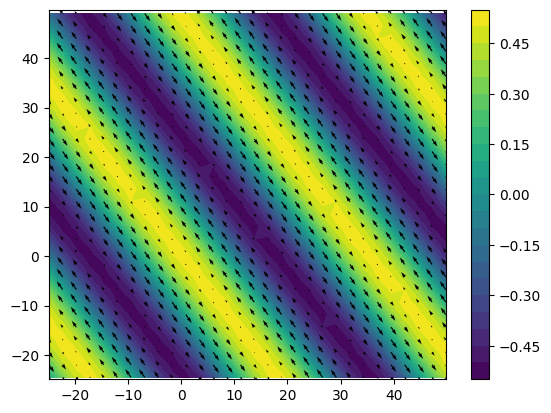

(np.float64(0.5286458877521414),
 'max error = 0.4775856459917337, min error = 0.4775801777433679')

In [ ]:
Plot_Spins(output_ar2q1,nmax)

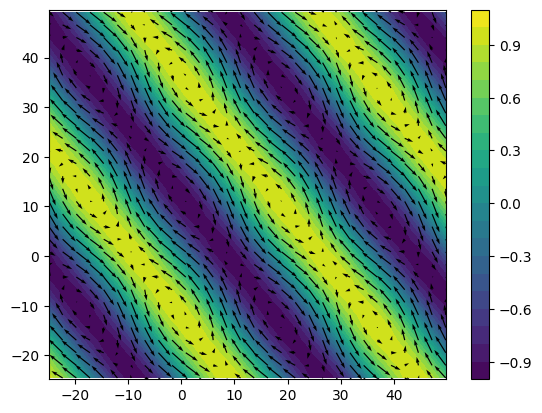

(np.float64(2.9184802130544085e-08),
 'max error = 0.00015806680414565122, min error = 3.2107390810498515e-06')

In [ ]:
Plot_Spins(output2q, nmax)

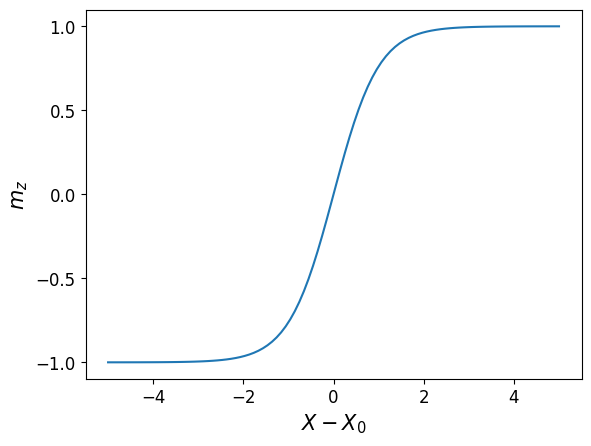

In [ ]:
x = np.linspace(-5,5,100)
y = (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))
plt.plot(x,y)
plt.ylabel("$m_z$", size = 15)
plt.xlabel("$X - X_0$", size = 15)
plt.tick_params(axis = "x", labelsize = 12)
plt.tick_params(axis = "y", labelsize = 12)
plt.gca().xaxis.set_major_locator(MultipleLocator(2))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

In [ ]:
-7*162/(9*337)

-0.37388724035608306

In [ ]:
7/9*(-0.03) + 337/324*(-0.03)**2

-0.022397222222222225